# **Klasifikasi Komentar Judi Online pada Platform YouTube**

## Deskripsi Proyek

Penelitian ini bertujuan untuk mengembangkan model klasifikasi teks berbasis machine learning menggunakan algoritma **Logistic Regression, Random Forest, dan Support Vector Machine (SVM)** dalam mendeteksi komentar yang mengandung promosi judi online pada platform YouTube. Model yang dikembangkan akan digunakan sebagai dasar dalam simulasi sistem moderasi preventif untuk menyaring komentar sebelum dipublikasikan.

## Dataset

Dataset yang digunakan merupakan kumpulan komentar YouTube yang telah dikumpulkan dan diberi label secara manual ke dalam dua kelas, yaitu:

- **0** : Komentar non-promosi judi online  
- **1** : Komentar promosi judi online  

Dataset memiliki beberapa atribut utama:
- `comment_id` : ID unik komentar
- `author` : Nama pengguna
- `comment_text` : Isi komentar
- `label` : Kelas target


# **Splitting Dataset**
Dataset akan dibagi menjadi dua bagian, yaitu:
- **Training Set** : 80% dari dataset akan digunakan untuk melatih model.
- **Testing Set** : 20% dari dataset akan digunakan untuk menguji performa model

In [80]:
import pandas as pd

# Load the dataset
data = pd.read_csv('dataset/lab/dataset_judol_labelled_full.csv')
data.shape

(37216, 4)

In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   comment_id    37216 non-null  object
 1   author        37216 non-null  object
 2   comment_text  37216 non-null  object
 3   label         37216 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.1+ MB


**Remove Duplikat data:**<br>
Data duplikat dihapus sebelum proses train-test split utk mencegah data leakage, yaitu kondisi ketika sampel yang sama terdapat pada data training dan data testing. Hal ini penting agar hasil evaluasi model mencerminkan kemampuan model dalam memprediksi data baru yang belum pernah dilihat sebelumnya

In [82]:
print(data['comment_text'].count())

37216


In [83]:
# Jumlah data di tiap label
jumlah_data_label0 = data[data['label'] == 0].shape[0]
jumlah_data_label1 = data[data['label'] == 1].shape[0]

print(f"Jumlah data (label 0): {jumlah_data_label0}")
print(f"Jumlah data (label 1): {jumlah_data_label1}")

Jumlah data (label 0): 28667
Jumlah data (label 1): 8549


In [84]:
# Hitung jumlah comment_text unik (semua data)
jumlah_comment_text_unik = data['comment_text'].nunique()

# Hitung jumlah comment_text unik dengan label 1
jumlah_comment_text_label1_unik = data.loc[data['label'] == 1, 'comment_text'].nunique()

print(f"Jumlah comment_text unik (total): {jumlah_comment_text_unik}")
print(f"Jumlah comment_text unik (label 1): {jumlah_comment_text_label1_unik}")

Jumlah comment_text unik (total): 32234
Jumlah comment_text unik (label 1): 5495


In [85]:
# Cek data duplikat berdasarkan comment_text
duplikat_comment_text = data[data.duplicated(subset='comment_text', keep=False)]
print(f"Jumlah data duplikat (comment_text): {duplikat_comment_text.shape[0]}")

Jumlah data duplikat (comment_text): 6894


In [86]:
# Hapus data duplikat berdasarkan comment_text
data = data.drop_duplicates(subset='comment_text', keep='first')
print(f"Jumlah data setelah menghapus duplikat: {data.shape[0]}")

Jumlah data setelah menghapus duplikat: 32234


In [87]:
# cek data duplikat berdasarkan comment_text setelah dihapus
duplikat_comment_text_after = data[data.duplicated(subset='comment_text', keep=False)]
print(f"Jumlah data duplikat (comment_text) setelah dihapus: {duplikat_comment_text_after.shape[0]}")

Jumlah data duplikat (comment_text) setelah dihapus: 0


**Split Data**

In [88]:
from sklearn.model_selection import train_test_split

# Prepare features (X) and target (y)
X = data[['comment_id', 'author', 'comment_text']]
y = data['label']

# Split dataset with 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

# Create train and test dataframes
train_df = pd.DataFrame({
    'comment_id': X_train['comment_id'],
    'author': X_train['author'],
    'comment_text': X_train['comment_text'],
    'label': y_train
}).reset_index(drop=True)

test_df = pd.DataFrame({
    'comment_id': X_test['comment_id'],
    'author': X_test['author'],
    'comment_text': X_test['comment_text'],
    'label': y_test
}).reset_index(drop=True)

# Save to CSV
train_df.to_csv('dataset/lab/train_set.csv', index=False, encoding='utf-8-sig')
test_df.to_csv('dataset/lab/test_set.csv', index=False, encoding='utf-8-sig')

print("\nTrain set saved to: dataset/lab/train_set.csv")
print("Test set saved to: dataset/lab/test_set.csv")

Train set size: 25787
Test set size: 6447

Train set saved to: dataset/lab/train_set.csv
Test set saved to: dataset/lab/test_set.csv


# **Modeling**

## Import Library

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score, roc_curve, auc

## Load Dataset

In [90]:
train_df = pd.read_csv("dataset/lab/train_set.csv")
test_df = pd.read_csv("dataset/lab/test_set.csv")

print(train_df.shape)
print(test_df.shape)

(25787, 4)
(6447, 4)


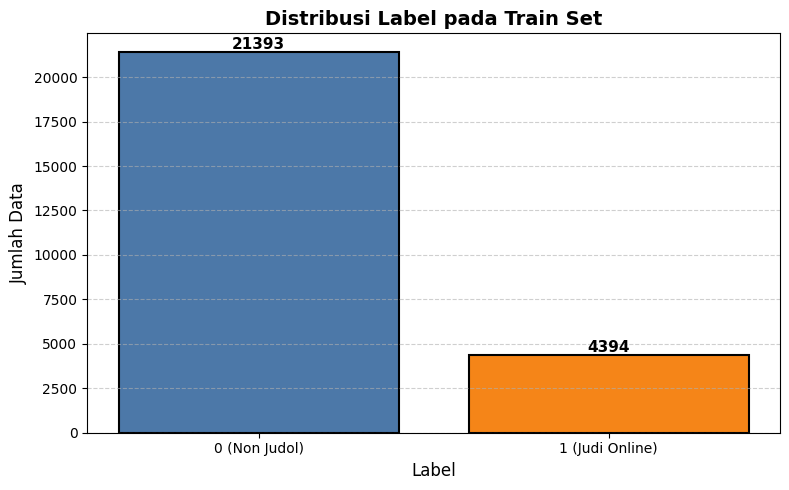

In [91]:
# visualisasi distribusi label pada train set
plt.figure(figsize=(8, 5))
train_label_counts = y_train.value_counts().sort_index()

colors = ['#4C78A8', '#F58518']  # Biru dan Orange
bars = plt.bar(train_label_counts.index, train_label_counts.values, color=colors, edgecolor='black', linewidth=1.5)

# Tambahkan nilai di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Distribusi Label pada Train Set', fontsize=14, fontweight='bold')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)
plt.xticks([0, 1], ['0 (Non Judol)', '1 (Judi Online)'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [92]:
# Pisahkan Feature dan Label
# data train
X_train = train_df["comment_text"]
y_train = train_df["label"]

# data test
X_test = test_df["comment_text"]
y_test = test_df["label"]

In [93]:
X_train.head(10)

0    bom dia meu irmão Deus te abençoe cada dia mai...
1    Semua bisa terjadi di 𝐴E𝑅О𝟴𝟾.Buktikan sendiri ...
2                                  GEMESSSSSSSSNYAAAAA
3                               😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂
4    Semoga laris nak jualannya..makasih mbak ..ada...
5                                Salam JEPE  𝑷𝑶𝑲𝑬𝑹𝑩𝑶𝑳𝑨
6    Ingin rasanya aq teriakin “ A dedeeee sawinyo ...
7    Abis nonton colab ghostranger indonesia x dms ...
8    lu lihat tuh kecerdasan marketing di Indonesia...
9                             Mas nya : Wah duit nih 😂
Name: comment_text, dtype: object

In [94]:
X_test.head(10)

0                                  Bikin apa kang Dede
1                     Kreatif bang kang dede ineon ini
2    😂😂manis baru nikah ,msh malu di omelin,ntar ka...
3                                                 Ayue
4    Gak percaya? Coba 𝐌𝐀𝐌𝐀𝐉𝐈𝐓𝐔 5 menit, liat hasil...
5    А𝙂𝘜S𝐓𝙊𝙏𝙊 jackpot gampang, WD lancar, apa lagi ...
6                     Masa Racun bisa keracunan hehehe
7                           Sekarang era nya maherzein
8                                    Mantaabz nyooo👍😁😁
9    ✌𝓦𝓔𝓣𝓞𝓝+88✌ selalu kasih pengalaman main yang m...
Name: comment_text, dtype: object

## Preprocessing

In [95]:
import re
import json
import unicodedata
import pandas as pd

# HARDCODE OBFUSCATION

OBF_MAP = {

    # Square Letters
    "🅰":"a","🅱":"b","🅲":"c","🅳":"d","🅴":"e",
    "🅵":"f","🅶":"g","🅷":"h","🅸":"i","🅹":"j",
    "🅺":"k","🅻":"l","🅼":"m","🅽":"n","🅾":"o",
    "🅿":"p","🆀":"q","🆁":"r","🆂":"s","🆃":"t",
    "🆄":"u","🆅":"v","🆆":"w","🆇":"x","🆈":"y","🆉":"z",

    # Square Letters VS16
    "🅰️":"a",
    "🅱️":"b",
    "🅾️":"o",
    "🅿️":"p",

    # Circled Lowercase
    "ⓐ":"a","ⓑ":"b","ⓒ":"c","ⓓ":"d","ⓔ":"e",
    "ⓕ":"f","ⓖ":"g","ⓗ":"h","ⓘ":"i","ⓙ":"j",
    "ⓚ":"k","ⓛ":"l","ⓜ":"m","ⓝ":"n","ⓞ":"o",
    "ⓟ":"p","ⓠ":"q","ⓡ":"r","ⓢ":"s","ⓣ":"t",
    "ⓤ":"u","ⓥ":"v","ⓦ":"w","ⓧ":"x","ⓨ":"y","ⓩ":"z",

    # Circled Uppercase
    "Ⓐ":"a","Ⓑ":"b","Ⓒ":"c","Ⓓ":"d","Ⓔ":"e",
    "Ⓕ":"f","Ⓖ":"g","Ⓗ":"h","Ⓘ":"i","Ⓙ":"j",
    "Ⓚ":"k","Ⓛ":"l","Ⓜ":"m","Ⓝ":"n","Ⓞ":"o",
    "Ⓟ":"p","Ⓠ":"q","Ⓡ":"r","Ⓢ":"s","Ⓣ":"t",
    "Ⓤ":"u","Ⓥ":"v","Ⓦ":"w","Ⓧ":"x","Ⓨ":"y","Ⓩ":"z",

    # Circled Numbers
    "⓪":"0","①":"1","②":"2","③":"3","④":"4",
    "⑤":"5","⑥":"6","⑦":"7","⑧":"8","⑨":"9",

    # Fancy Numbers
    "❶":"1","❷":"2","❸":"3","❹":"4","❺":"5",
    "❻":"6","❼":"7","❽":"8","❾":"9",

    # Emoji Numbers
    "0️⃣":"0","1️⃣":"1","2️⃣":"2","3️⃣":"3",
    "4️⃣":"4","5️⃣":"5","6️⃣":"6",
    "7️⃣":"7","8️⃣":"8","9️⃣":"9",

    # Symbol Substitution
    "@":"a",
    "$":"s",
    "!":"i",
    "€":"e"
}

# LOAD JSON MAPPING (override hardcode)

with open("dataset/obfuscation_mapping.json", encoding="utf-8") as f:
    json_map = json.load(f)

OBF_MAP.update(json_map)

# LOAD SLANG DICTIONARY

SLANG_MAP = {}

with open("dataset/slang_indo.csv", encoding="utf-8") as f:
    for line in f:
        key, value = line.strip().split(",", 1)
        SLANG_MAP[key] = value

# COMPILE REGEX

obf_pattern = re.compile(
    "|".join(
        map(
            re.escape,
            sorted(
                OBF_MAP.keys(),
                key=len,
                reverse=True
            )
        )
    )
)

# HELPER FUNCTIONS

def replace_obfuscation(text):
    return obf_pattern.sub(
        lambda m: OBF_MAP.get(m.group(0), m.group(0)),
        text
    )


def replace_slang(text):

    words = text.split()

    words = [
        SLANG_MAP.get(word, word)
        for word in words
    ]

    return " ".join(words)


# MAIN PREPROCESSING PIPELINE

def preprocess_text(text):

    # 1. Missing Value
    if pd.isna(text):
        return ""

    text = str(text)

    # 2. Unicode Normalization (NFKC)
    text = unicodedata.normalize("NFKC", text)

    # 3. Replace Obfuscation
    text = replace_obfuscation(text)

    # 4. Unicode Normalization (NFKD)
    text = unicodedata.normalize("NFKD", text)

    text = "".join(
        c for c in text
        if not unicodedata.combining(c)
    )

    # 5. Lowercase
    text = text.lower()

    # 6. URL Normalization
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' iniurl ',
        text
    )

    # 7. Email Normalization
    text = re.sub(
        r'\S+@\S+',
        ' iniemail ',
        text
    )

    # 8. Slang Normalization
    text = replace_slang(text)

    # 9. Remove Special Characters
    text = re.sub(
        r'[^a-z0-9\s]',
        ' ',
        text
    )

    # 10. Gabungkan huruf terpisah
    # contoh:
    # s c a t t e r
    # menjadi
    # scatter
    merge_pattern = r'(?:\b(?:[a-z0-9]\s+){2,}[a-z0-9]\b)'

    text = re.sub(
        merge_pattern,
        lambda m: m.group(0).replace(" ", ""),
        text
    )

    # 11. Remove Multiple Spaces
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text

In [96]:
X_train.head(10)

0    bom dia meu irmão Deus te abençoe cada dia mai...
1    Semua bisa terjadi di 𝐴E𝑅О𝟴𝟾.Buktikan sendiri ...
2                                  GEMESSSSSSSSNYAAAAA
3                               😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂
4    Semoga laris nak jualannya..makasih mbak ..ada...
5                                Salam JEPE  𝑷𝑶𝑲𝑬𝑹𝑩𝑶𝑳𝑨
6    Ingin rasanya aq teriakin “ A dedeeee sawinyo ...
7    Abis nonton colab ghostranger indonesia x dms ...
8    lu lihat tuh kecerdasan marketing di Indonesia...
9                             Mas nya : Wah duit nih 😂
Name: comment_text, dtype: object

In [97]:
X_test.head(10)

0                                  Bikin apa kang Dede
1                     Kreatif bang kang dede ineon ini
2    😂😂manis baru nikah ,msh malu di omelin,ntar ka...
3                                                 Ayue
4    Gak percaya? Coba 𝐌𝐀𝐌𝐀𝐉𝐈𝐓𝐔 5 menit, liat hasil...
5    А𝙂𝘜S𝐓𝙊𝙏𝙊 jackpot gampang, WD lancar, apa lagi ...
6                     Masa Racun bisa keracunan hehehe
7                           Sekarang era nya maherzein
8                                    Mantaabz nyooo👍😁😁
9    ✌𝓦𝓔𝓣𝓞𝓝+88✌ selalu kasih pengalaman main yang m...
Name: comment_text, dtype: object

In [98]:
# Apply ke train dan test:
X_train = X_train.apply(preprocess_text)
X_test = X_test.apply(preprocess_text)

In [99]:
X_train.head(10)

0    bom dia meu irmao deus te abencoe cada dia mai...
1    semua bisa terjadi di aer 88 buktikan sendiri ...
2                                  gemessssssssnyaaaaa
3                                                     
4    semoga laris anak jualannya makasih mbak ada m...
5                                 salam jepe pokerbola
6    ingin rasanya saya teriakin a dedeeee sawinyo ...
7    abis nonton colab ghostranger indonesia x dms ...
8    kamu lihat tuh kecerdasan marketing di indones...
9                                 mas nya wah duit nih
Name: comment_text, dtype: object

In [100]:
X_test.head(10)

0                                  bikin apa kang dede
1                     kreatif bang kang dede ineon ini
2    manis baru nikah msh malu di omelin ntar kalok...
3                                                 ayue
4    tidak percaya coba mamajitu 5 menit liat hasil...
5    gustoto jackpot gampang wd lancar apa lagi yan...
6                     masa racun bisa keracunan hehehe
7                           sekarang era nya maherzein
8                                       mantaabz nyooo
9    weton 88 selalu kasih pengalaman main yang mak...
Name: comment_text, dtype: object

In [101]:
# cek missing value setelah preprocessing
print("Jumlah missing value pada X_train:", X_train.isnull().sum())
print("Jumlah missing value pada X_test:", X_test.isnull().sum())

Jumlah missing value pada X_train: 0
Jumlah missing value pada X_test: 0


## TF-IDF

In [102]:
def tfidf_transform(X_train, X_test, max_features=5000, ngram_range=(1,1)):
    tfidf = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)
    return X_train_tfidf, X_test_tfidf

X_train_tfidf, X_test_tfidf = tfidf_transform(X_train, X_test)

## Evaluasi Model

In [103]:
def evaluate_model(model, X_test, y_test, title="Model"):

    y_pred = model.predict(X_test)

    print(f"=== {title} ===")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='viridis',
        cbar=True
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.show()

## Learning Curve

In [104]:
def plot_learning_curve(model, X, y, title="Learning Curve"):

    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure(figsize=(8,5))

    plt.plot(
        train_sizes,
        train_mean,
        marker='o',
        label='Training Score'
    )

    plt.plot(
        train_sizes,
        test_mean,
        marker='o',
        label='Validation Score'
    )

    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.title(title)

    plt.grid(
        True,
        linestyle='--',
        alpha=0.7
    )

    plt.legend()

    plt.show()

## SKENARIO - BASELINE
Eksperimen baseline dilakukan untuk mengevaluasi performa awal algoritma klasifikasi (Logistic Regression, Random Forest, dan Support Vector Machine) pada dataset asli tanpa penerapan teknik penanganan ketidakseimbangan data. Hasil dari eksperimen ini digunakan sebagai acuan untuk membandingkan efektivitas eksperimen lainnya.

### **Logistic Regression**

=== Baseline - LR ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      5348
           1       0.98      0.86      0.92      1099

    accuracy                           0.97      6447
   macro avg       0.98      0.93      0.95      6447
weighted avg       0.97      0.97      0.97      6447



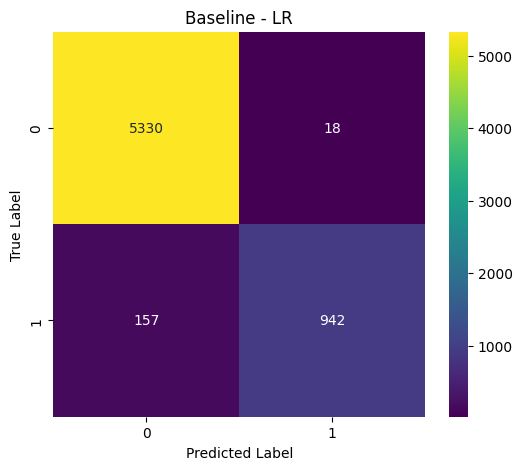

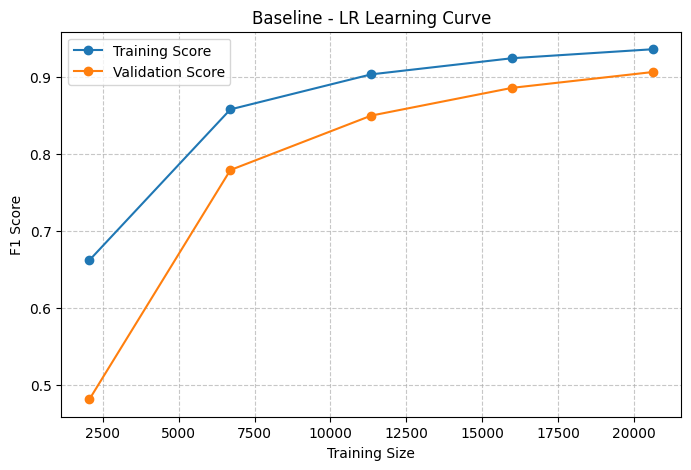

In [105]:
model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42)
model_lr.fit(X_train_tfidf, y_train)

evaluate_model(model_lr, X_test_tfidf, y_test, "Baseline - LR")
plot_learning_curve(model_lr, X_train_tfidf, y_train, "Baseline - LR Learning Curve")

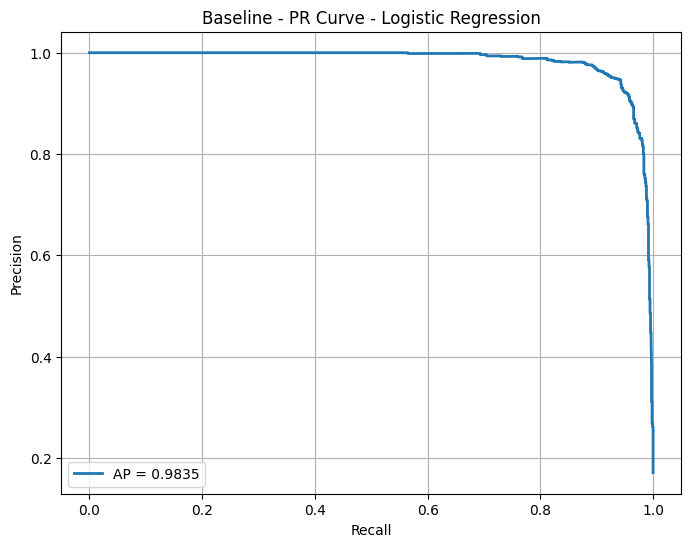

In [106]:
# Probabilitas kelas positif
y_score = model_lr.predict_proba(X_test_tfidf)[:, 1]

# Hitung Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# Average Precision
ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision,
         linewidth=2,
         label=f'AP = {ap:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Baseline - PR Curve - Logistic Regression")
plt.grid(True)
plt.legend()
plt.show()

**Threshold Analysis**

In [107]:
threshold_list = np.arange(0.1, 1.0, 0.1)

results = []

for t in threshold_list:

    y_pred = (y_score >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        t,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(threshold_df)

   Threshold  Precision    Recall  F1-score
0        0.1   0.700129  0.989991  0.820204
1        0.2   0.878311  0.965423  0.919809
2        0.3   0.941818  0.942675  0.942246
3        0.4   0.964182  0.906278  0.934334
4        0.5   0.981250  0.857143  0.915007
5        0.6   0.988479  0.780710  0.872395
6        0.7   0.996109  0.698817  0.821390
7        0.8   1.000000  0.556870  0.715371
8        0.9   1.000000  0.330300  0.496580


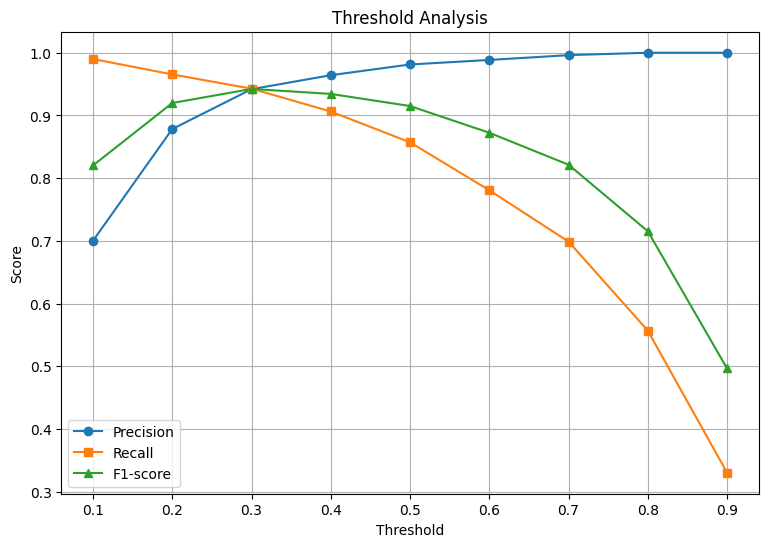

In [108]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='s',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker='^',
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.grid(True)
plt.legend()

plt.show()

**Cross Validation Baseline LR**

In [109]:
# Cross Validation Baseline LR
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_lr_cv = LogisticRegression(
    max_iter=1000,
    random_state=42
)

cv_scores = cross_val_score(
    estimator=model_lr_cv,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("===== Cross Validation Baseline LR =====")
print("F1-score tiap fold :", cv_scores)
print("Mean F1-score      :", cv_scores.mean())
print("Std Dev            :", cv_scores.std())

===== Cross Validation Baseline LR =====
F1-score tiap fold : [0.896      0.90830769 0.90709046 0.90820073 0.908645  ]
Mean F1-score      : 0.9056487788630196
Std Dev            : 0.00485256732816665


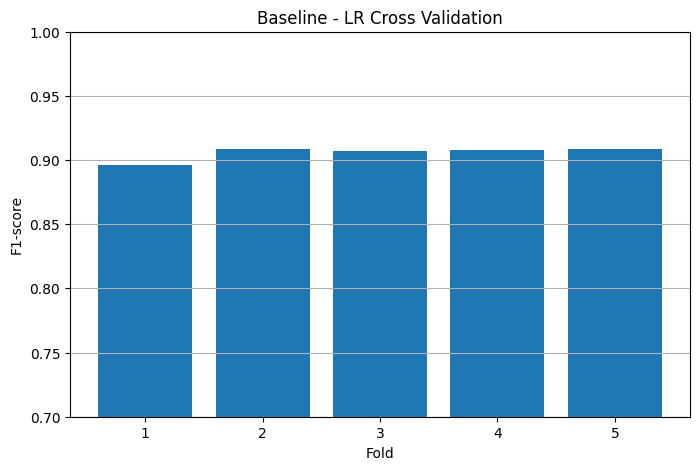

In [110]:
plt.figure(figsize=(8,5))

plt.bar(range(1,6), cv_scores)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Baseline - LR Cross Validation")
plt.ylim(0.7,1.0)
plt.grid(axis='y')

plt.show()

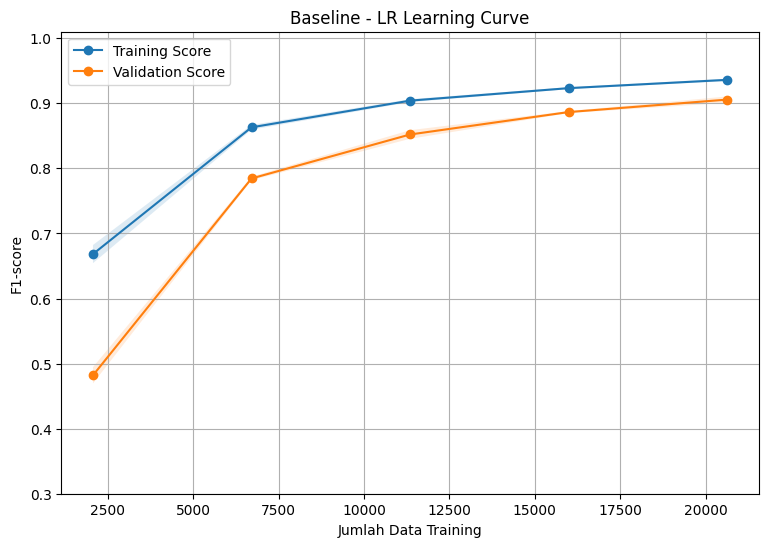

In [111]:
# Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model
model_lr_lc = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Hitung learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_lr_lc,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Rata-rata tiap fold
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(9,6))

plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

# Area deviasi
plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.15
)

plt.title("Baseline - LR Learning Curve")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()
plt.ylim(0.3,1.01)

plt.show()

### **Random Forest**

=== Baseline - RF ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5348
           1       0.98      0.93      0.96      1099

    accuracy                           0.99      6447
   macro avg       0.98      0.96      0.97      6447
weighted avg       0.99      0.99      0.99      6447



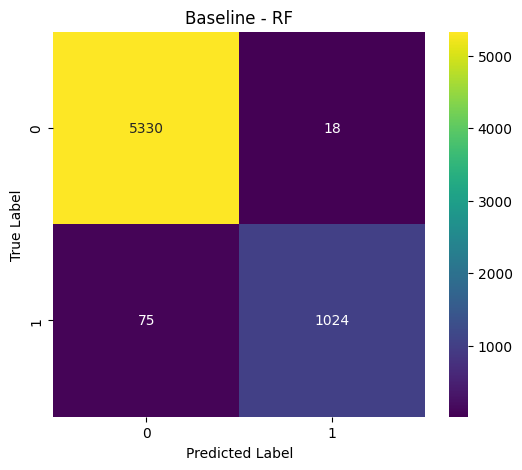

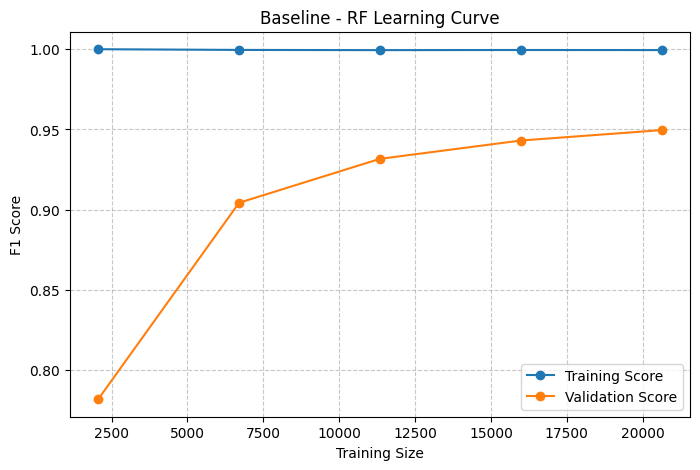

In [112]:
# Model Random Forest (baseline)
model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

# Training
model_rf.fit(X_train_tfidf, y_train)

# Evaluasi
evaluate_model(model_rf, X_test_tfidf, y_test, "Baseline - RF")

# Learning Curve
plot_learning_curve(model_rf, X_train_tfidf, y_train, "Baseline - RF Learning Curve")

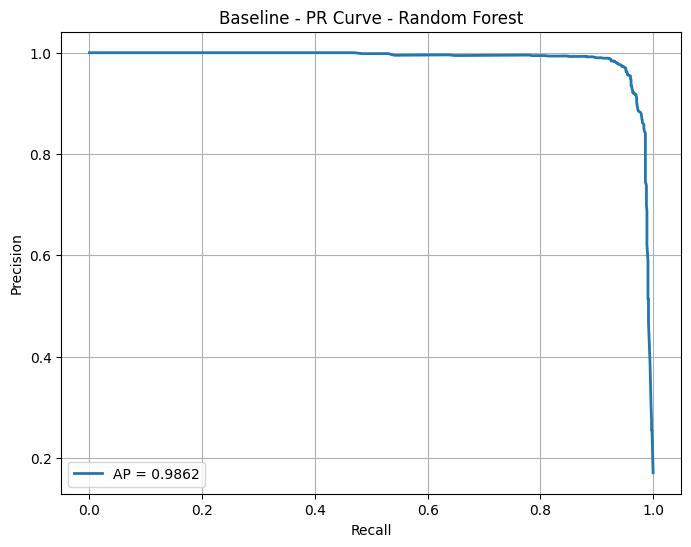

In [113]:
# Probabilitas kelas positif
y_score = model_rf.predict_proba(X_test_tfidf)[:, 1]

# Hitung Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# Average Precision
ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision,
         linewidth=2,
         label=f'AP = {ap:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Baseline - PR Curve - Random Forest")
plt.grid(True)
plt.legend()
plt.show()

**Threshold Analysis**

In [114]:
threshold_list = np.arange(0.1, 1.0, 0.1)

results = []

for t in threshold_list:

    y_pred = (y_score >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        t,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(threshold_df)

   Threshold  Precision    Recall  F1-score
0        0.1   0.699292  0.988171  0.819005
1        0.2   0.858618  0.983621  0.916879
2        0.3   0.921807  0.965423  0.943111
3        0.4   0.957117  0.954504  0.955809
4        0.5   0.980880  0.933576  0.956643
5        0.6   0.989980  0.898999  0.942299
6        0.7   0.993421  0.824386  0.901044
7        0.8   0.994674  0.679709  0.807568
8        0.9   1.000000  0.405823  0.577346


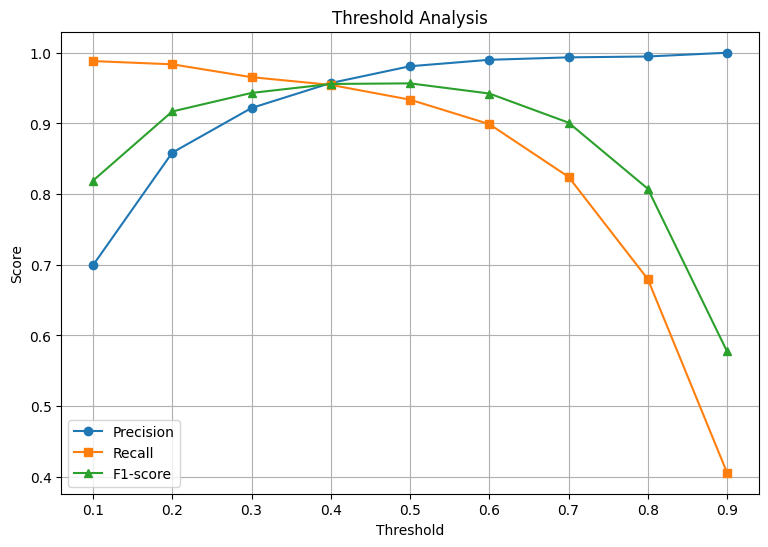

In [115]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='s',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker='^',
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.grid(True)
plt.legend()

plt.show()

**Cross Validation Baseline RF**

In [116]:
# Cross Validation Baseline RF
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_rf_cv = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

cv_scores = cross_val_score(
    estimator=model_rf_cv,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("===== Cross Validation Baseline RF =====")
print("F1-score tiap fold :", cv_scores)
print("Mean F1-score      :", cv_scores.mean())
print("Std Dev            :", cv_scores.std())

===== Cross Validation Baseline RF =====
F1-score tiap fold : [0.93884683 0.9506463  0.95550351 0.96041909 0.94823529]
Mean F1-score      : 0.9507302046594109
Std Dev            : 0.007267810113279434


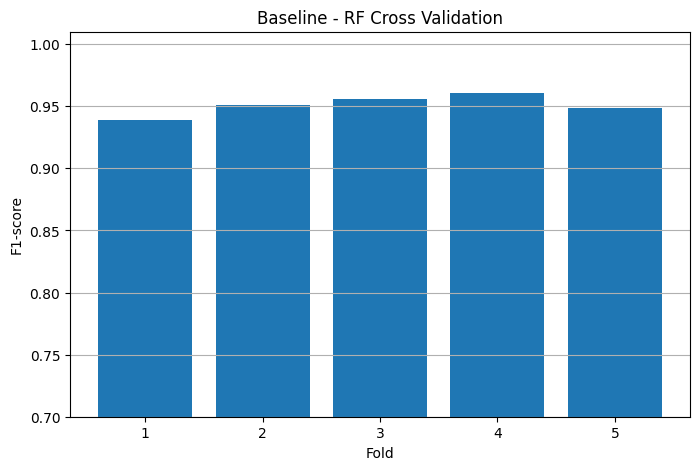

In [117]:
plt.figure(figsize=(8,5))

plt.bar(range(1,6), cv_scores)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Baseline - RF Cross Validation")
plt.ylim(0.7,1.01)
plt.grid(axis='y')

plt.show()

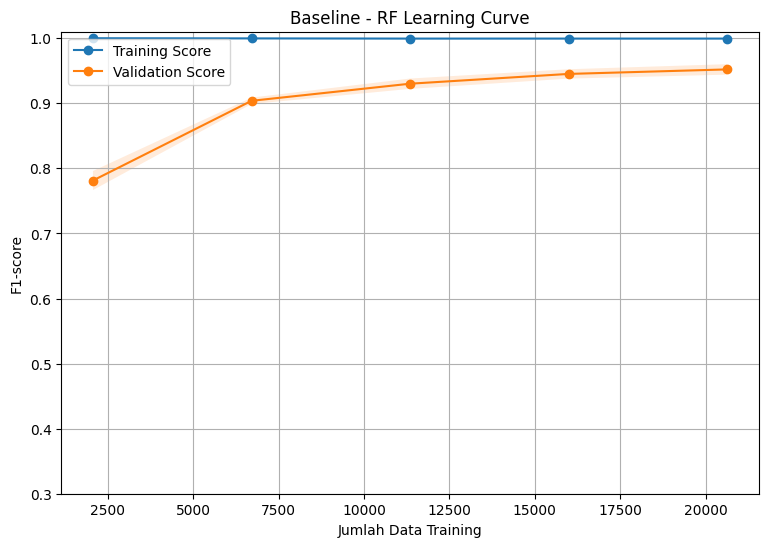

In [118]:
# Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model
model_rf_lc = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Hitung learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_rf_lc,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Rata-rata tiap fold
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(9,6))

plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

# Area deviasi
plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.15
)

plt.title("Baseline - RF Learning Curve")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()
plt.ylim(0.3,1.01)

plt.show()

### **Support Vector Machine (SVM)**

=== Baseline - SVM ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5348
           1       0.98      0.95      0.97      1099

    accuracy                           0.99      6447
   macro avg       0.99      0.97      0.98      6447
weighted avg       0.99      0.99      0.99      6447



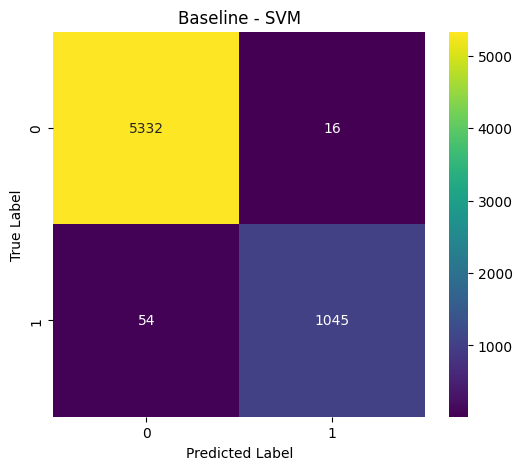

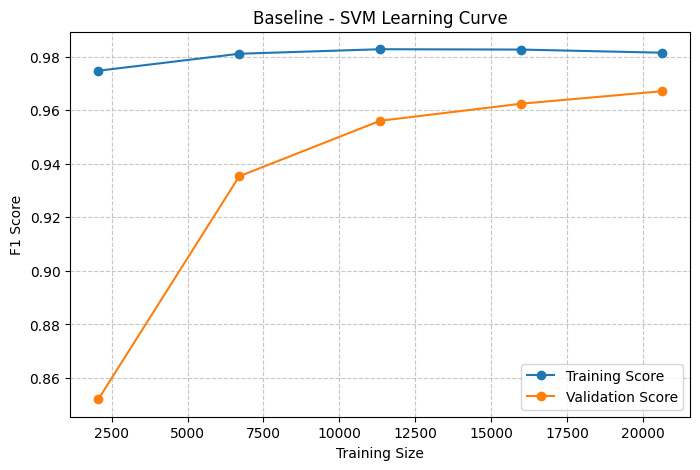

In [119]:
# Model SVM (baseline)
model_svm = SVC(
    kernel='linear',
    probability=True,
    random_state=42
    )

# Training
model_svm.fit(X_train_tfidf, y_train)

# Evaluasi
evaluate_model(model_svm, X_test_tfidf, y_test, "Baseline - SVM")

# Learning Curve (opsional, tanpa SMOTE)
plot_learning_curve(model_svm, X_train_tfidf, y_train, "Baseline - SVM Learning Curve")

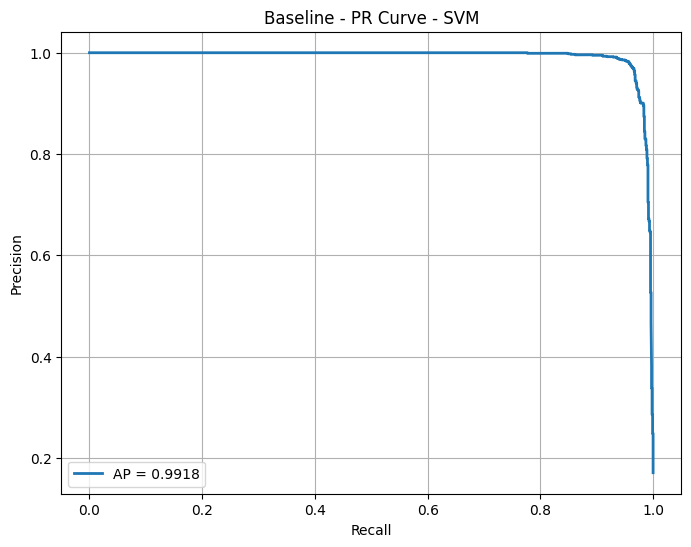

In [120]:
# Probabilitas kelas positif
y_score = model_svm.predict_proba(X_test_tfidf)[:, 1]

# Hitung Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# Average Precision
ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision,
         linewidth=2,
         label=f'AP = {ap:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Baseline - PR Curve - SVM")
plt.grid(True)
plt.legend()
plt.show()

**Threshold Analysis**

In [121]:
threshold_list = np.arange(0.1, 1.0, 0.1)

results = []

for t in threshold_list:

    y_pred = (y_score >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        t,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(threshold_df)

   Threshold  Precision    Recall  F1-score
0        0.1   0.928696  0.971793  0.949755
1        0.2   0.955117  0.968153  0.961591
2        0.3   0.968950  0.965423  0.967183
3        0.4   0.974170  0.960874  0.967476
4        0.5   0.979516  0.957234  0.968247
5        0.6   0.983114  0.953594  0.968129
6        0.7   0.985755  0.944495  0.964684
7        0.8   0.991321  0.935396  0.962547
8        0.9   0.992141  0.919017  0.954180


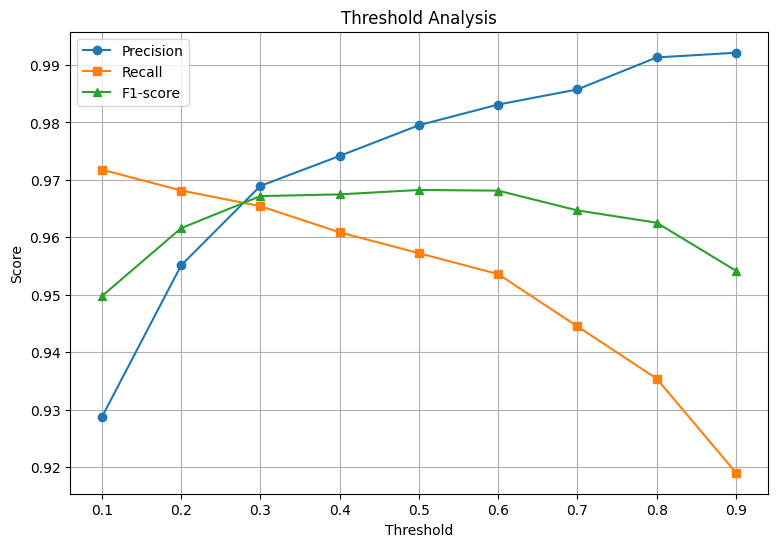

In [122]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='s',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker='^',
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.grid(True)
plt.legend()

plt.show()

**Cross-Validation SVM**

In [123]:
# Cross Validation Baseline SVM
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_svm_cv = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

cv_scores = cross_val_score(
    estimator=model_svm_cv,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("===== Cross Validation Baseline SVM =====")
print("F1-score tiap fold :", cv_scores)
print("Mean F1-score      :", cv_scores.mean())
print("Std Dev            :", cv_scores.std())

===== Cross Validation Baseline SVM =====
F1-score tiap fold : [0.96583671 0.96976744 0.97172533 0.96811594 0.9675174 ]
Mean F1-score      : 0.9685925656271557
Std Dev            : 0.002008603525202062


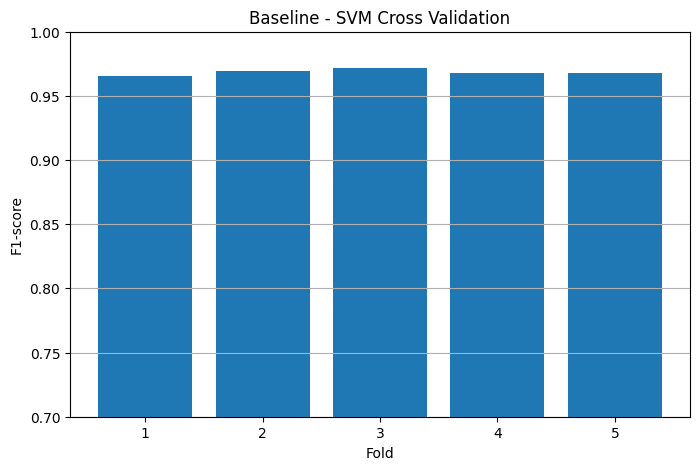

In [124]:
plt.figure(figsize=(8,5))

plt.bar(range(1,6), cv_scores)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Baseline - SVM Cross Validation")
plt.ylim(0.7,1.0)
plt.grid(axis='y')

plt.show()

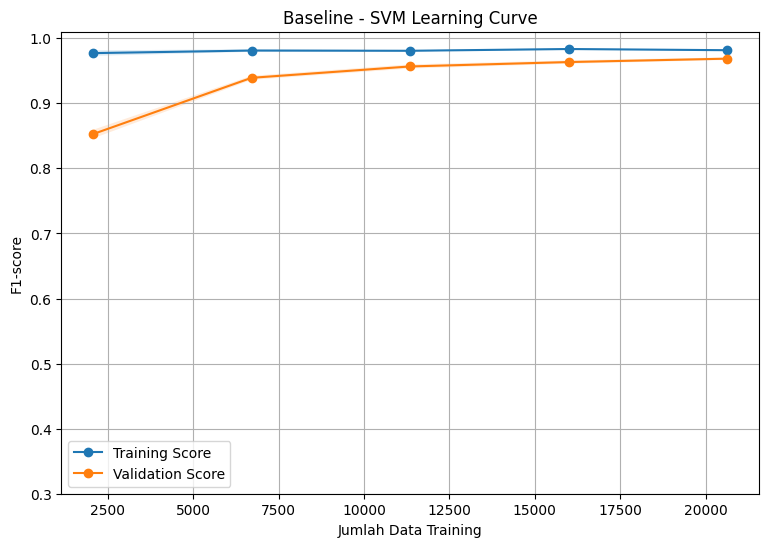

In [125]:
# Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model
model_svm_lc = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

# Hitung learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_svm_lc,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Rata-rata tiap fold
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(9,6))

plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

# Area deviasi
plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.15
)

plt.title("Baseline - SVM Learning Curve")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()
plt.ylim(0.3,1.01)

plt.show()

## SKENARIO - CLASS WEIGHTING
Eksperimen ini dilakukan dengan menerapkan teknik **class weighting** pada algoritma klasifikasi untuk menangani ketidakseimbangan kelas pada dataset. Teknik ini memberikan bobot lebih tinggi pada kelas minoritas (komentar promosi judi online) sehingga model lebih sensitif terhadap kelas tersebut.

### **Class Weighting - LR**

=== Class Weighting - LR ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5348
           1       0.92      0.96      0.94      1099

    accuracy                           0.98      6447
   macro avg       0.96      0.97      0.96      6447
weighted avg       0.98      0.98      0.98      6447



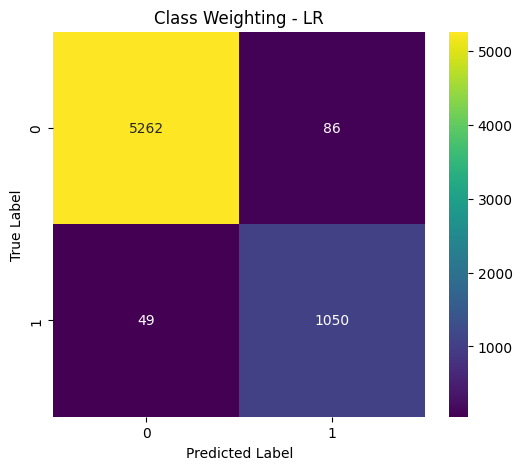

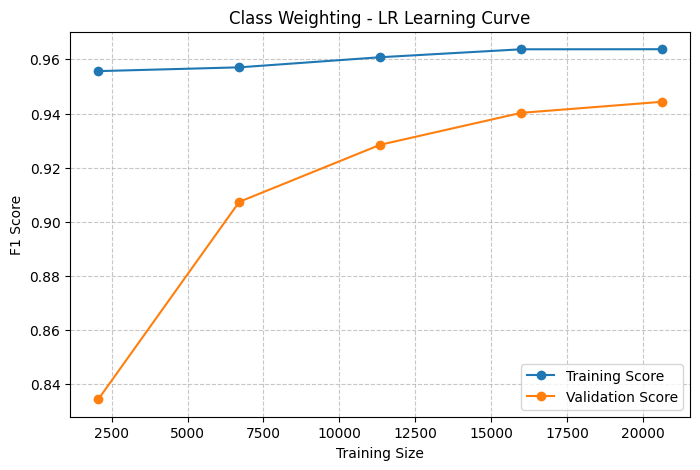

In [126]:
model_lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42)
model_lr.fit(X_train_tfidf, y_train)

evaluate_model(model_lr, X_test_tfidf, y_test, "Class Weighting - LR")
plot_learning_curve(model_lr, X_train_tfidf, y_train, "Class Weighting - LR Learning Curve")

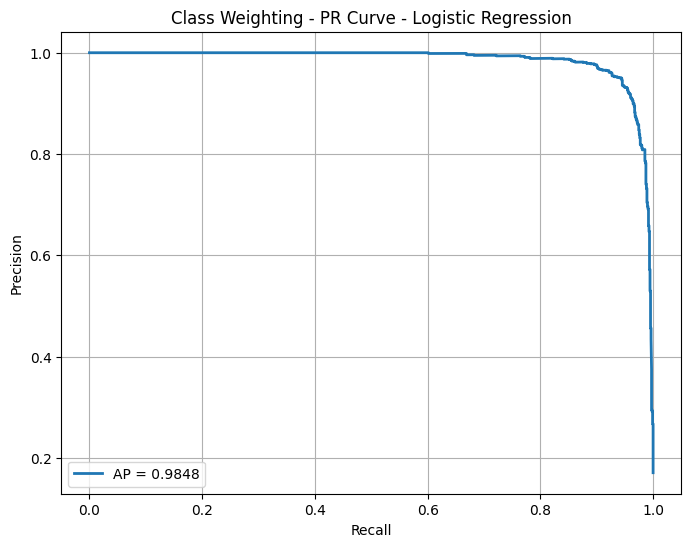

In [127]:
# Probabilitas kelas positif
y_score = model_lr.predict_proba(X_test_tfidf)[:, 1]

# Hitung Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# Average Precision
ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision,
         linewidth=2,
         label=f'AP = {ap:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Class Weighting - PR Curve - Logistic Regression")
plt.grid(True)
plt.legend()
plt.show()

**Threshold Analysis**

In [128]:
threshold_list = np.arange(0.1, 1.0, 0.1)

results = []

for t in threshold_list:

    y_pred = (y_score >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        t,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(threshold_df)

   Threshold  Precision    Recall  F1-score
0        0.1   0.435388  0.996360  0.605977
1        0.2   0.667483  0.991811  0.797950
2        0.3   0.809309  0.980892  0.886878
3        0.4   0.877888  0.968153  0.920814
4        0.5   0.924296  0.955414  0.939597
5        0.6   0.952602  0.932666  0.942529
6        0.7   0.971541  0.900819  0.934844
7        0.8   0.988030  0.826206  0.899901
8        0.9   0.998638  0.666970  0.799782


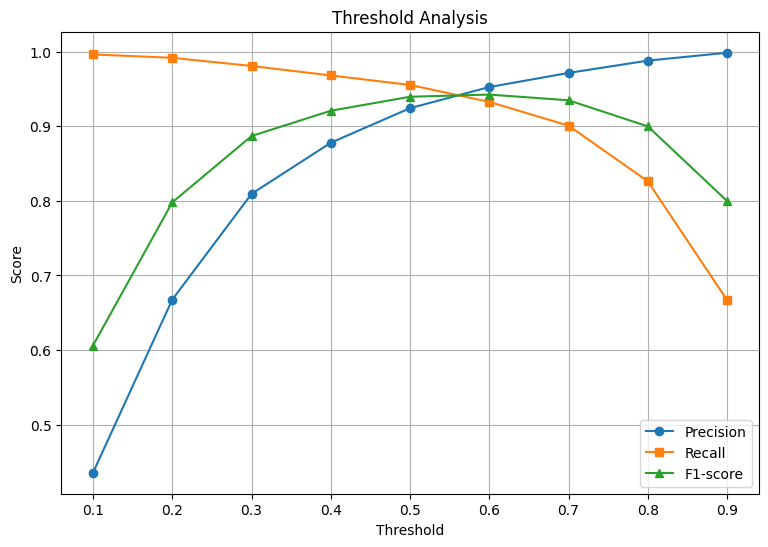

In [129]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='s',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker='^',
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.grid(True)
plt.legend()

plt.show()

**Cross Validation - LR Class Weighting**

In [130]:
# Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_lr_cv = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

cv_scores = cross_val_score(
    estimator=model_lr_cv,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("=====Class Weighting - LR Cross Validation=====")
print("F1-score tiap fold :", cv_scores)
print("Mean F1-score      :", cv_scores.mean())
print("Std Dev            :", cv_scores.std())

=====Class Weighting - LR Cross Validation=====
F1-score tiap fold : [0.94577977 0.94189944 0.94818942 0.94032348 0.95408735]
Mean F1-score      : 0.9460558895679909
Std Dev            : 0.004884036188031222


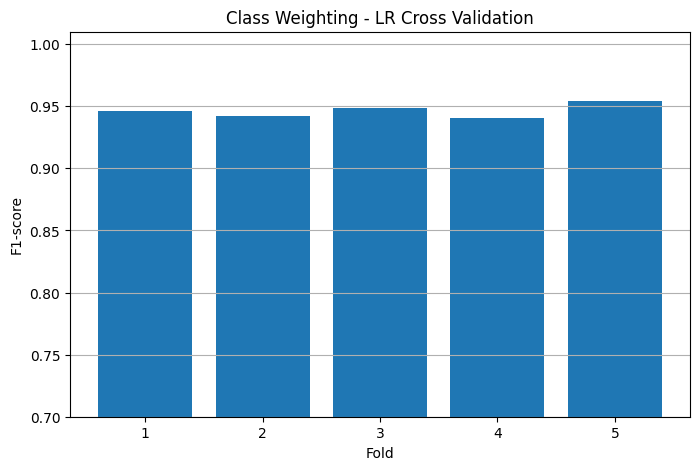

In [131]:
plt.figure(figsize=(8,5))

plt.bar(range(1,6), cv_scores)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Class Weighting - LR Cross Validation")
plt.ylim(0.7,1.01)
plt.grid(axis='y')

plt.show()

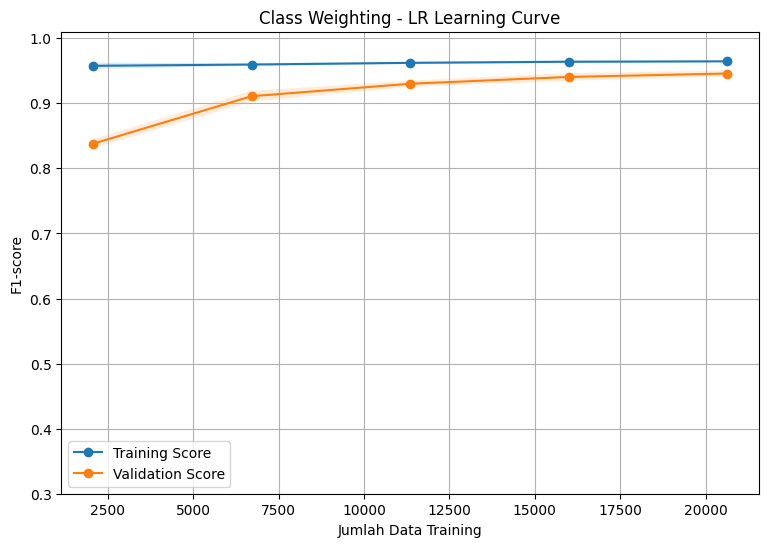

In [132]:
# Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model
model_lr_lc = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Hitung learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_lr_lc,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Rata-rata tiap fold
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(9,6))

plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

# Area deviasi
plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.15
)

plt.title("Class Weighting - LR Learning Curve")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()
plt.ylim(0.3,1.01)

plt.show()

### **Class Weighting - RF**

=== Class Weighting - RF ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      5348
           1       0.98      0.91      0.94      1099

    accuracy                           0.98      6447
   macro avg       0.98      0.95      0.97      6447
weighted avg       0.98      0.98      0.98      6447



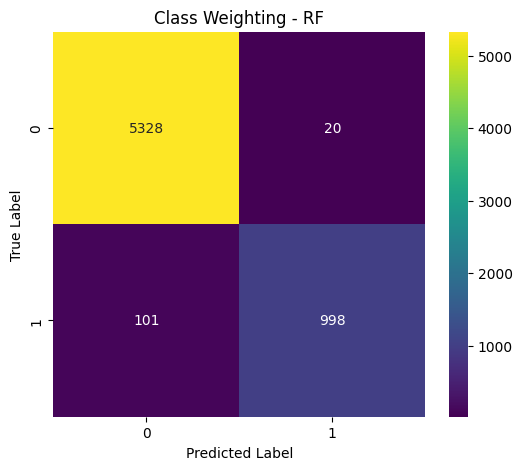

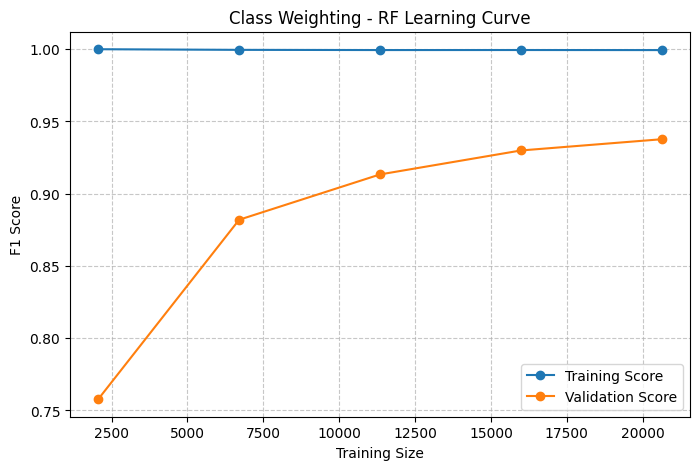

In [133]:
# Model Random Forest (baseline)
model_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42)

# Training
model_rf.fit(X_train_tfidf, y_train)

# Evaluasi
evaluate_model(model_rf, X_test_tfidf, y_test, "Class Weighting - RF")

# Learning Curve
plot_learning_curve(model_rf, X_train_tfidf, y_train, "Class Weighting - RF Learning Curve")

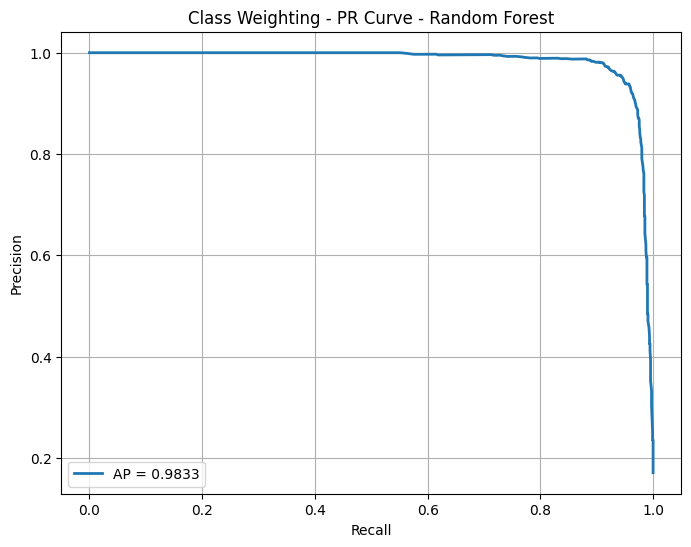

In [134]:
# Probabilitas kelas positif
y_score = model_rf.predict_proba(X_test_tfidf)[:, 1]

# Hitung Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# Average Precision
ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision,
         linewidth=2,
         label=f'AP = {ap:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Class Weighting - PR Curve - Random Forest")
plt.grid(True)
plt.legend()
plt.show()

**Threshold Analysis**

In [135]:
threshold_list = np.arange(0.1, 1.0, 0.1)

results = []

for t in threshold_list:

    y_pred = (y_score >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        t,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(threshold_df)

   Threshold  Precision    Recall  F1-score
0        0.1   0.595721  0.988171  0.743326
1        0.2   0.791330  0.979982  0.875610
2        0.3   0.892797  0.969973  0.929786
3        0.4   0.955679  0.941765  0.948671
4        0.5   0.980392  0.909918  0.943841
5        0.6   0.987526  0.864422  0.921883
6        0.7   0.995031  0.728844  0.841387
7        0.8   1.000000  0.550500  0.710094
8        0.9   1.000000  0.321201  0.486226


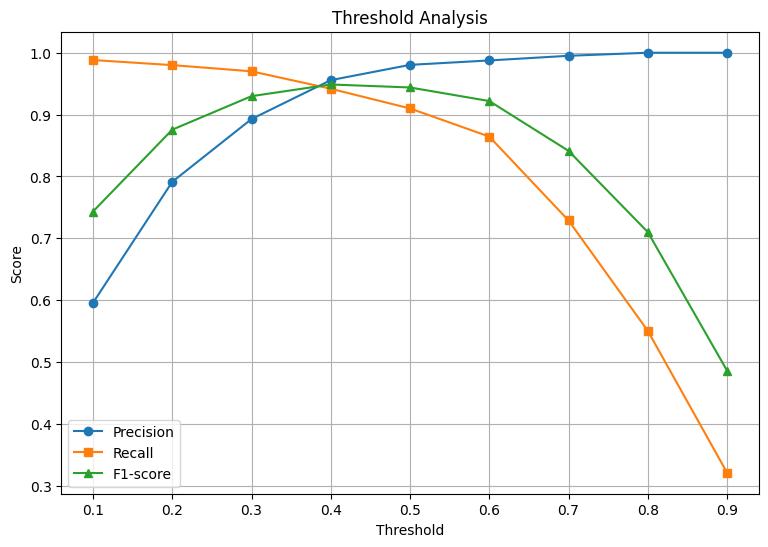

In [136]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='s',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker='^',
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.grid(True)
plt.legend()

plt.show()

**Cross Validation**

In [137]:
# Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_rf_cv = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

cv_scores = cross_val_score(
    estimator=model_rf_cv,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("===== Cross Validation - Class Weighting RF =====")
print("F1-score tiap fold :", cv_scores)
print("Mean F1-score      :", cv_scores.mean())
print("Std Dev            :", cv_scores.std())

===== Cross Validation - Class Weighting RF =====
F1-score tiap fold : [0.9263406  0.93768546 0.93971631 0.94656489 0.93971631]
Mean F1-score      : 0.9380047141222013
Std Dev            : 0.006561846168190572


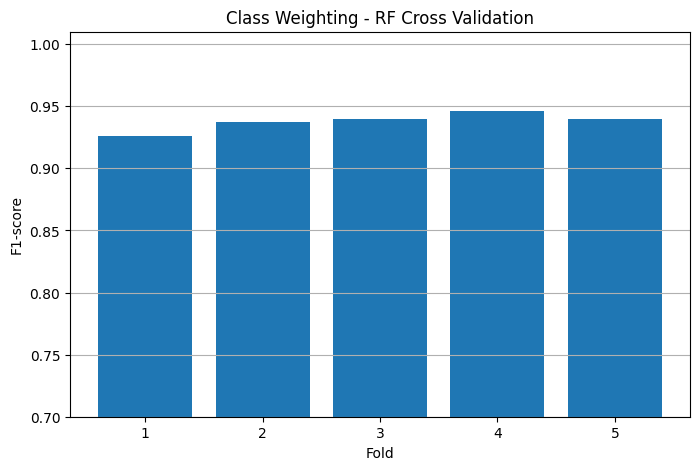

In [138]:
plt.figure(figsize=(8,5))

plt.bar(range(1,6), cv_scores)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Class Weighting - RF Cross Validation")
plt.ylim(0.7,1.01)
plt.grid(axis='y')

plt.show()

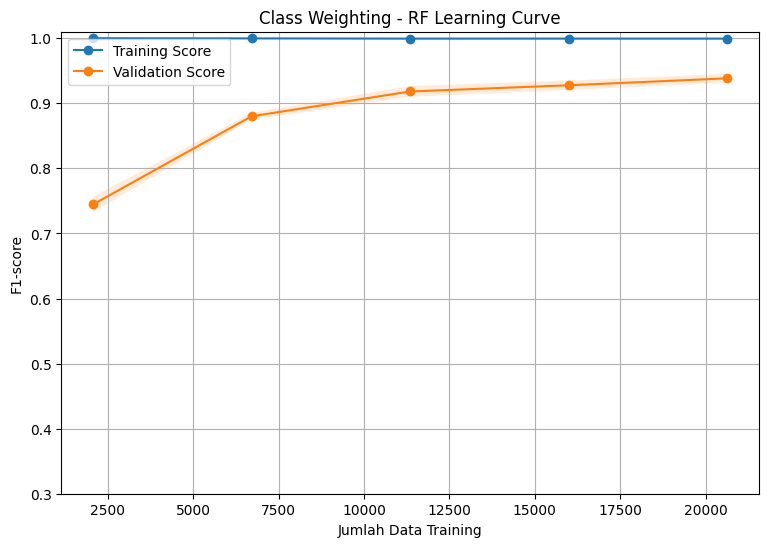

In [139]:
# Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model
model_rf_lc = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

# Hitung learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_rf_lc,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Rata-rata tiap fold
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(9,6))

plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

# Area deviasi
plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.15
)

plt.title("Class Weighting - RF Learning Curve")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()
plt.ylim(0.3,1.01)

plt.show()

### **Class Weighting - SVM**

=== Class Weighting - SVM ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5348
           1       0.96      0.96      0.96      1099

    accuracy                           0.99      6447
   macro avg       0.98      0.98      0.98      6447
weighted avg       0.99      0.99      0.99      6447



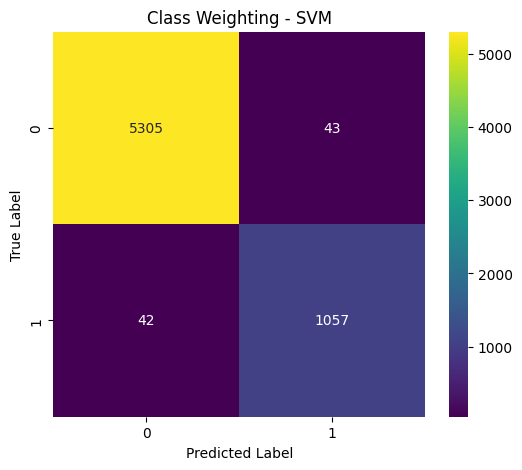

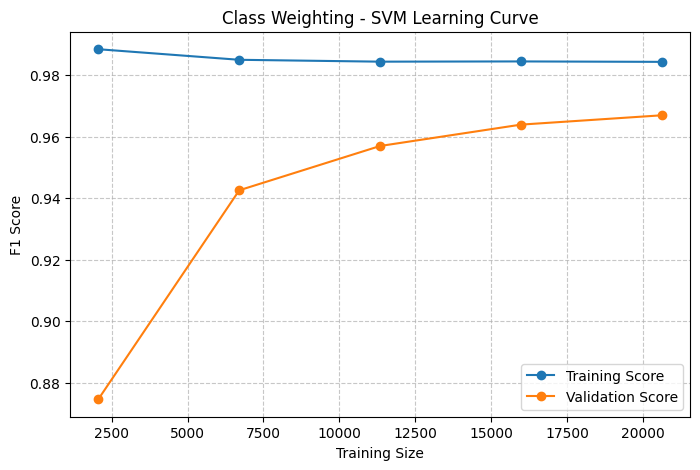

In [140]:
# Model SVM
model_svm = SVC(
    kernel='linear',
    class_weight='balanced',
    probability=True,
    random_state=42
    )

# Training
model_svm.fit(X_train_tfidf, y_train)

# Evaluasi
evaluate_model(model_svm, X_test_tfidf, y_test, "Class Weighting - SVM")

# Learning Curve (opsional, tanpa SMOTE)
plot_learning_curve(model_svm, X_train_tfidf, y_train, "Class Weighting - SVM Learning Curve")

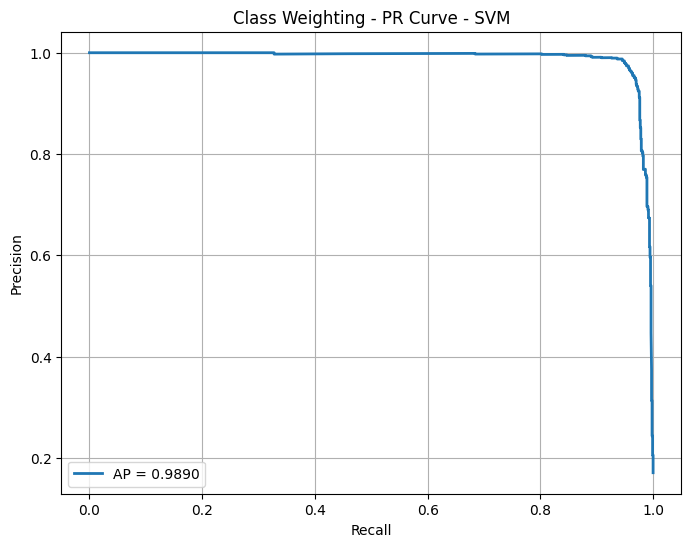

In [141]:
# Probabilitas kelas positif
y_score = model_svm.predict_proba(X_test_tfidf)[:, 1]

# Hitung Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# Average Precision
ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision,
         linewidth=2,
         label=f'AP = {ap:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Class Weighting - PR Curve - SVM")
plt.grid(True)
plt.legend()
plt.show()

**Threshold Analysis**

In [142]:
threshold_list = np.arange(0.1, 1.0, 0.1)

results = []

for t in threshold_list:

    y_pred = (y_score >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        t,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(threshold_df)

   Threshold  Precision    Recall  F1-score
0        0.1   0.903960  0.976342  0.938758
1        0.2   0.935145  0.970883  0.952679
2        0.3   0.957505  0.963603  0.960544
3        0.4   0.965201  0.959054  0.962118
4        0.5   0.973148  0.956324  0.964663
5        0.6   0.980263  0.949045  0.964401
6        0.7   0.987607  0.942675  0.964618
7        0.8   0.990272  0.926297  0.957217
8        0.9   0.991911  0.892630  0.939655


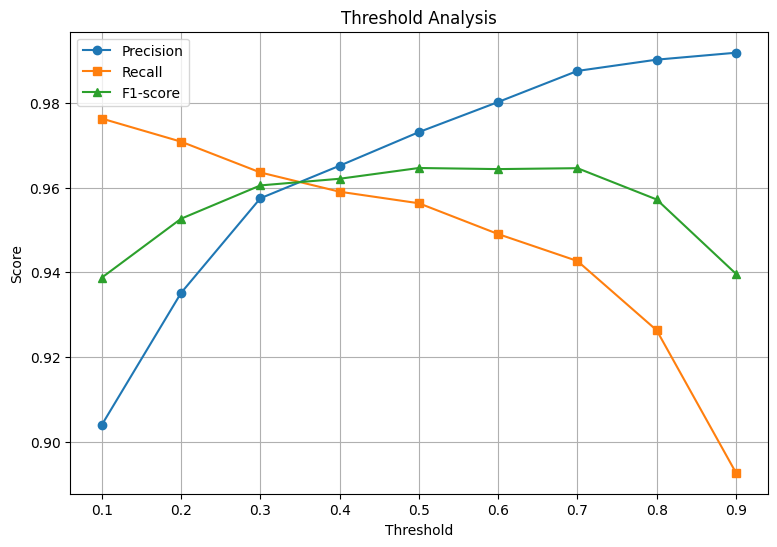

In [143]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='s',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker='^',
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.grid(True)
plt.legend()

plt.show()

**Cross-Validation Analysis**

In [144]:
# Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_svm_cv = SVC(
    kernel='linear',
    class_weight='balanced',
    probability=True,
    random_state=42
)

cv_scores = cross_val_score(
    estimator=model_svm_cv,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("===== Cross Validation - Class Weighting SVM =====")
print("F1-score tiap fold :", cv_scores)
print("Mean F1-score      :", cv_scores.mean())
print("Std Dev            :", cv_scores.std())

===== Cross Validation - Class Weighting SVM =====
F1-score tiap fold : [0.96664782 0.96976612 0.96836158 0.96661007 0.96818182]
Mean F1-score      : 0.9679134825067894
Std Dev            : 0.0011837070903471724


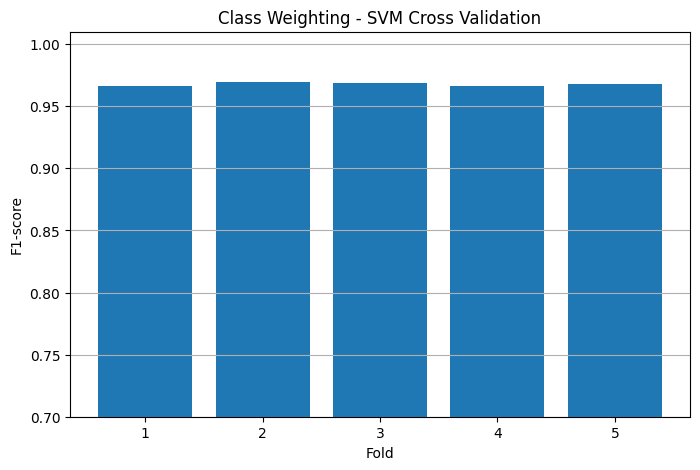

In [145]:
plt.figure(figsize=(8,5))

plt.bar(range(1,6), cv_scores)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Class Weighting - SVM Cross Validation")
plt.ylim(0.7,1.01)
plt.grid(axis='y')

plt.show()

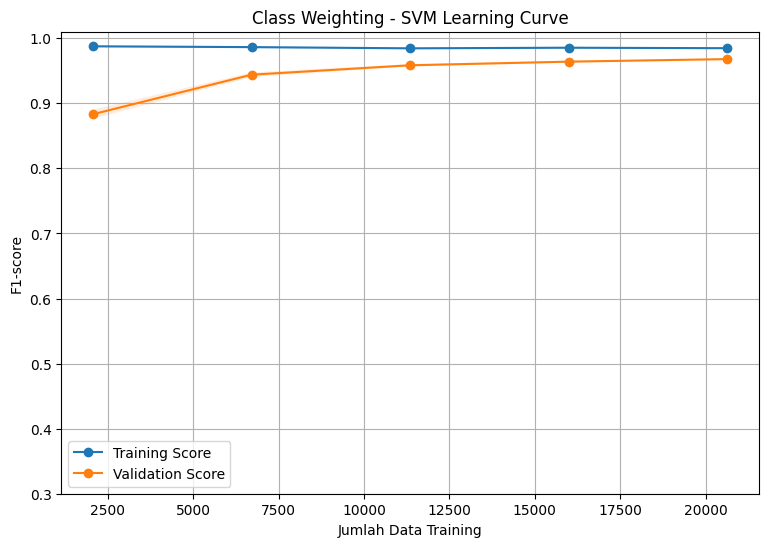

In [146]:
# Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model
model_svm_lc = SVC(
    kernel='linear',
    class_weight='balanced',
    probability=True,
    random_state=42
)

# Hitung learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_svm_lc,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Rata-rata tiap fold
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(9,6))

plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

# Area deviasi
plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.15
)

plt.title("Class Weighting - SVM Learning Curve")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()
plt.ylim(0.3,1.01)

plt.show()

## SKENARIO - SMOTE
Eksperimen oversampling menggunakan SMOTE bertujuan untuk mengatasi ketidakseimbangan distribusi kelas dengan menambahkan sampel sintetis pada kelas minoritas. Eksperimen ini dilakukan untuk mengetahui apakah penambahan data pada kelas minoritas dapat meningkatkan kemampuan model dalam mendeteksi komentar promosi judi online.

### **SMOTE - LR**

=== SMOTE - LR ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5348
           1       0.92      0.96      0.94      1099

    accuracy                           0.98      6447
   macro avg       0.96      0.97      0.96      6447
weighted avg       0.98      0.98      0.98      6447



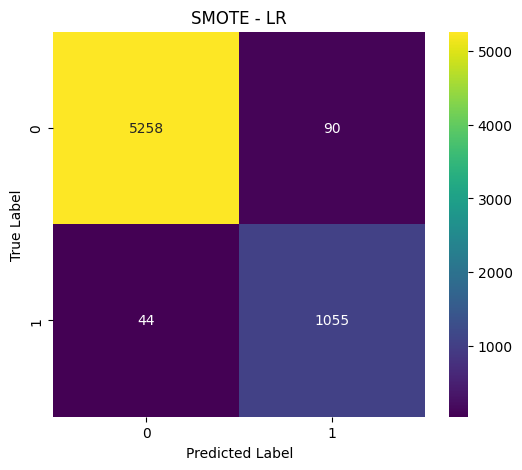

c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
2 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\li

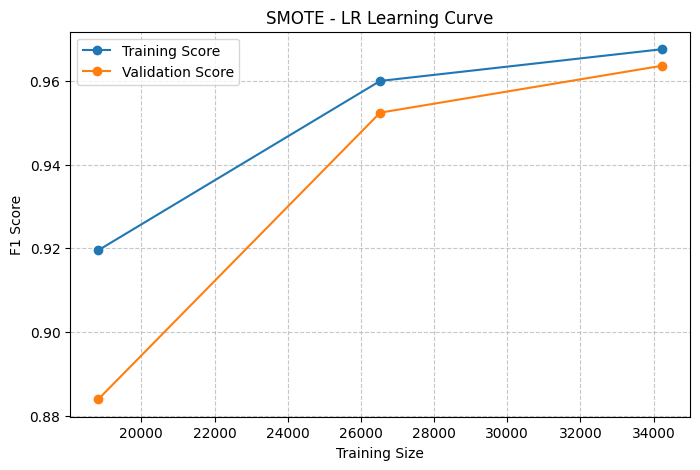

In [147]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

model_lr_smote = LogisticRegression(max_iter=1000, random_state=42)
model_lr_smote.fit(X_train_smote, y_train_smote)

evaluate_model(model_lr_smote, X_test_tfidf, y_test, "SMOTE - LR")
plot_learning_curve(model_lr_smote, X_train_smote, y_train_smote, "SMOTE - LR Learning Curve")

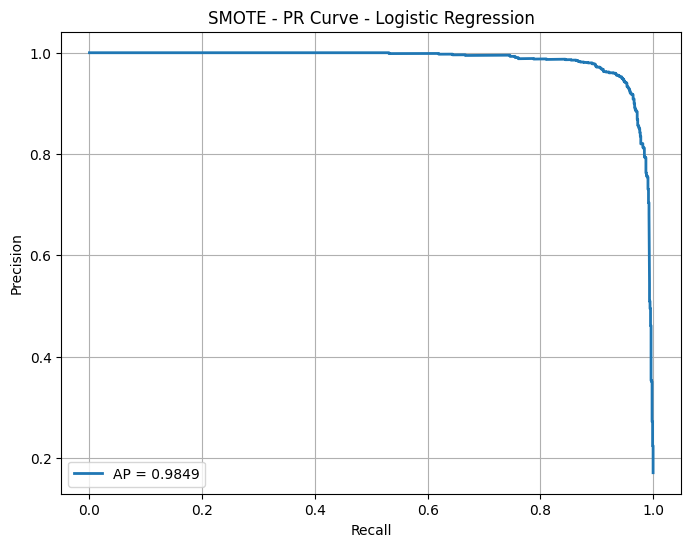

In [148]:
# Probabilitas kelas positif
y_score = model_lr_smote.predict_proba(X_test_tfidf)[:, 1]

# Hitung Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# Average Precision
ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision,
         linewidth=2,
         label=f'AP = {ap:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("SMOTE - PR Curve - Logistic Regression")
plt.grid(True)
plt.legend()
plt.show()

**Threshold Analysis**

In [149]:
threshold_list = np.arange(0.1, 1.0, 0.1)

results = []

for t in threshold_list:

    y_pred = (y_score >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        t,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(threshold_df)

   Threshold  Precision    Recall  F1-score
0        0.1   0.368067  0.996360  0.537555
1        0.2   0.683584  0.992721  0.809647
2        0.3   0.802076  0.984531  0.883987
3        0.4   0.871126  0.971793  0.918710
4        0.5   0.921397  0.959964  0.940285
5        0.6   0.948040  0.946315  0.947177
6        0.7   0.961796  0.916288  0.938490
7        0.8   0.982546  0.870792  0.923300
8        0.9   0.990499  0.758872  0.859351


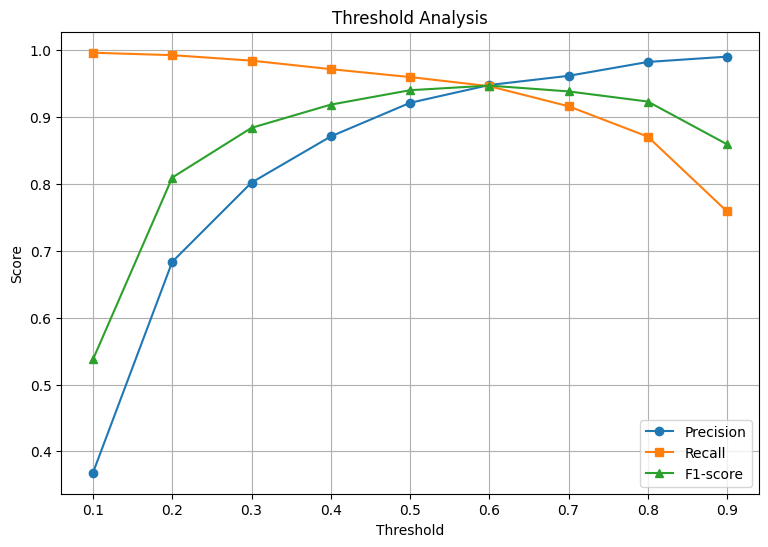

In [150]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='s',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker='^',
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.grid(True)
plt.legend()

plt.show()

**Cross-Validation Analysis**

In [151]:
# Cross Validation SMOTE + Logistic Regression
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_lr_smote_cv = LogisticRegression(
    max_iter=1000,
    random_state=42
)

cv_scores = cross_val_score(
    estimator=model_lr_smote_cv,
    X=X_train_smote,
    y=y_train_smote,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("===== Cross Validation SMOTE + Logistic Regression =====")
print("F1-score tiap fold :", cv_scores)
print("Mean F1-score      :", cv_scores.mean())
print("Std Dev            :", cv_scores.std())

===== Cross Validation SMOTE + Logistic Regression =====
F1-score tiap fold : [0.96487897 0.96217635 0.96191954 0.9646807  0.96528689]
Mean F1-score      : 0.9637884914208177
Std Dev            : 0.0014368268445957841


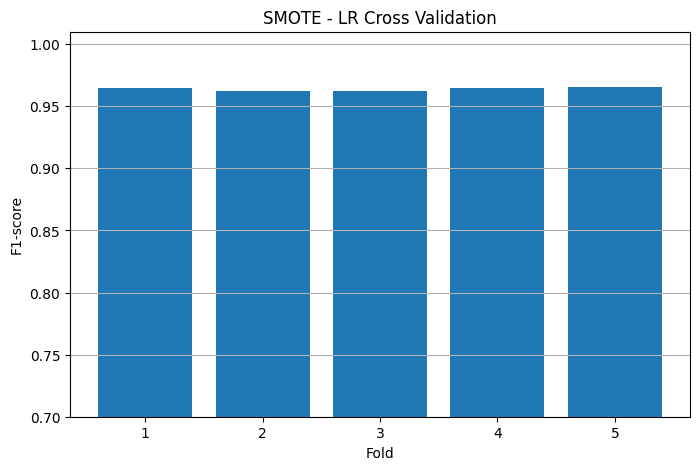

In [152]:
plt.figure(figsize=(8,5))

plt.bar(range(1,6), cv_scores)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("SMOTE - LR Cross Validation")
plt.ylim(0.7,1.01)
plt.grid(axis='y')

plt.show()

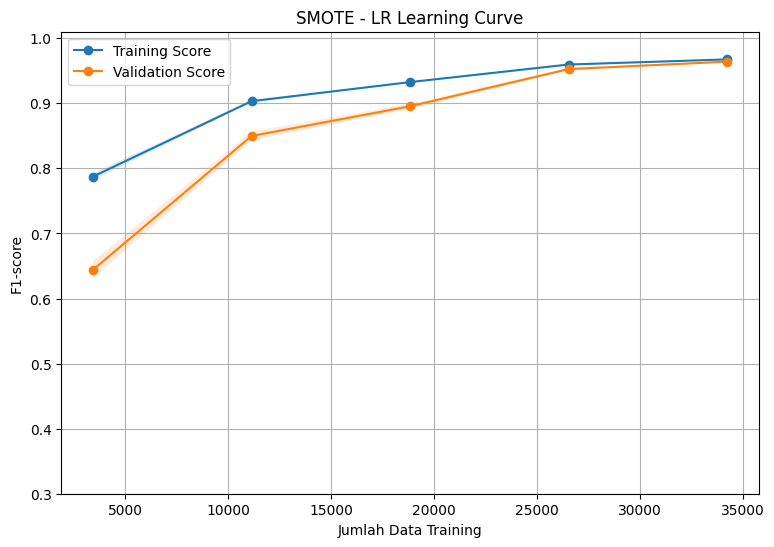

In [153]:
# Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model untuk learning curve
model_lr_smote_lc = LogisticRegression(max_iter=1000, random_state=42)

# Hitung learning curve pada data hasil SMOTE
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_lr_smote_lc,
    X=X_train_smote,
    y=y_train_smote,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Rata-rata dan std tiap fold
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(9,6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15)

plt.title("SMOTE - LR Learning Curve")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()
plt.ylim(0.3,1.01)

plt.show()


### **SMOTE - RF**

=== SMOTE - RF ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5348
           1       0.95      0.93      0.94      1099

    accuracy                           0.98      6447
   macro avg       0.97      0.96      0.96      6447
weighted avg       0.98      0.98      0.98      6447



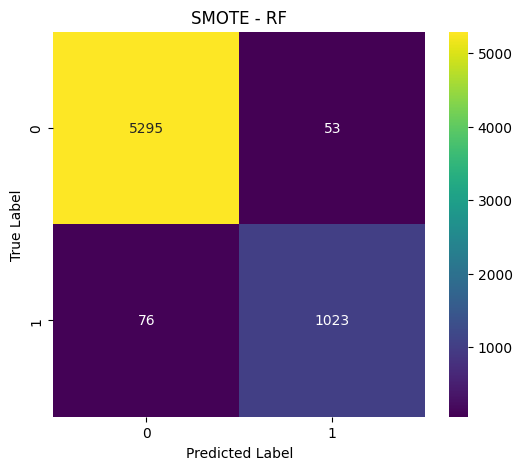

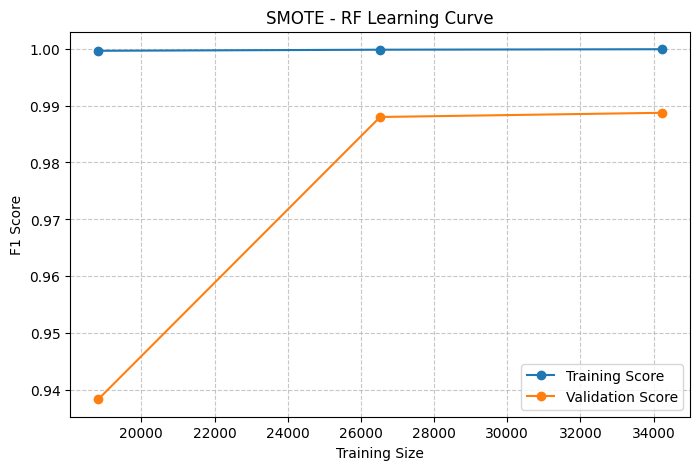

In [154]:
model_rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42)
model_rf_smote.fit(X_train_smote, y_train_smote)

evaluate_model(model_rf_smote, X_test_tfidf, y_test, "SMOTE - RF")
plot_learning_curve(model_rf_smote, X_train_smote, y_train_smote, "SMOTE - RF Learning Curve")

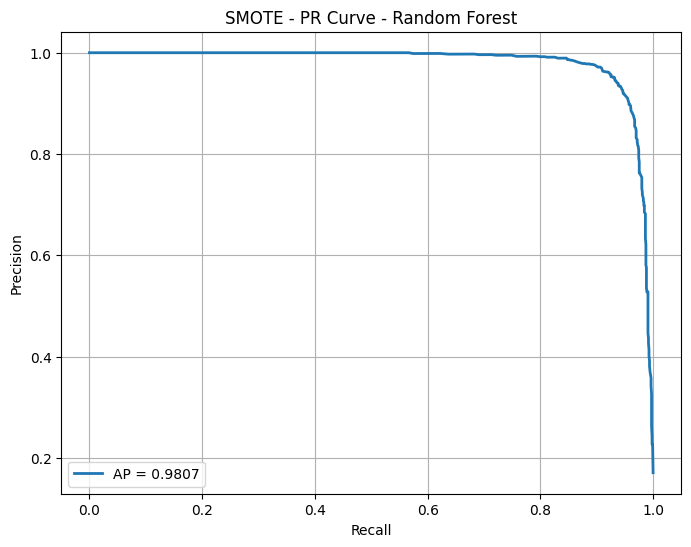

In [155]:
# Probabilitas kelas positif
y_score = model_rf_smote.predict_proba(X_test_tfidf)[:, 1]

# Hitung Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# Average Precision
ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision,
         linewidth=2,
         label=f'AP = {ap:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("SMOTE - PR Curve - Random Forest")
plt.grid(True)
plt.legend()
plt.show()

**Threshold Analysis**

In [156]:
threshold_list = np.arange(0.1, 1.0, 0.1)

results = []

for t in threshold_list:

    y_pred = (y_score >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        t,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(threshold_df)

   Threshold  Precision    Recall  F1-score
0        0.1   0.503700  0.990901  0.667893
1        0.2   0.672457  0.986351  0.799705
2        0.3   0.804054  0.974522  0.881119
3        0.4   0.895586  0.959964  0.926658
4        0.5   0.950789  0.931756  0.941176
5        0.6   0.975272  0.897179  0.934597
6        0.7   0.991121  0.812557  0.893000
7        0.8   0.997226  0.654231  0.790110
8        0.9   1.000000  0.439490  0.610619


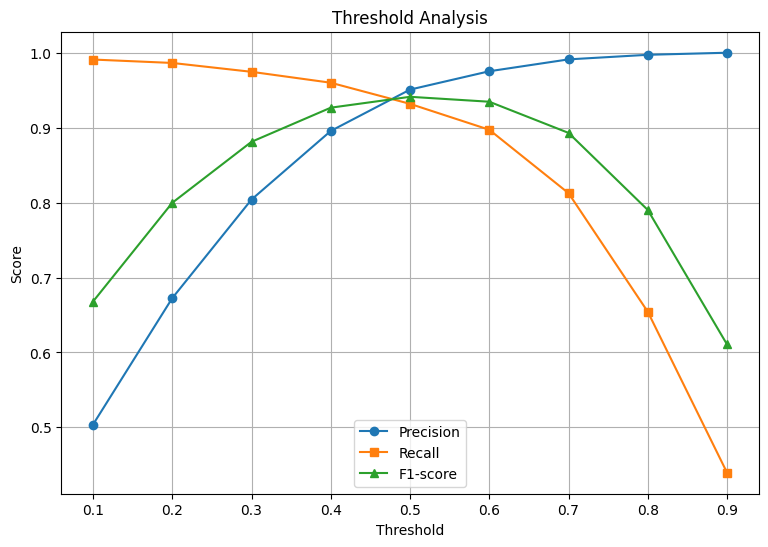

In [157]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='s',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker='^',
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.grid(True)
plt.legend()

plt.show()

**Cross-Validation Analysis**

In [158]:
# Cross Validation SMOTE + RF
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_rf_smote_cv = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

cv_scores = cross_val_score(
    estimator=model_rf_smote_cv,
    X=X_train_smote,
    y=y_train_smote,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("===== Cross Validation SMOTE + RF =====")
print("F1-score tiap fold :", cv_scores)
print("Mean F1-score      :", cv_scores.mean())
print("Std Dev            :", cv_scores.std())


===== Cross Validation SMOTE + RF =====
F1-score tiap fold : [0.98768873 0.98718845 0.99044512 0.98811189 0.98928239]
Mean F1-score      : 0.9885433143944645
Std Dev            : 0.001176026031095126


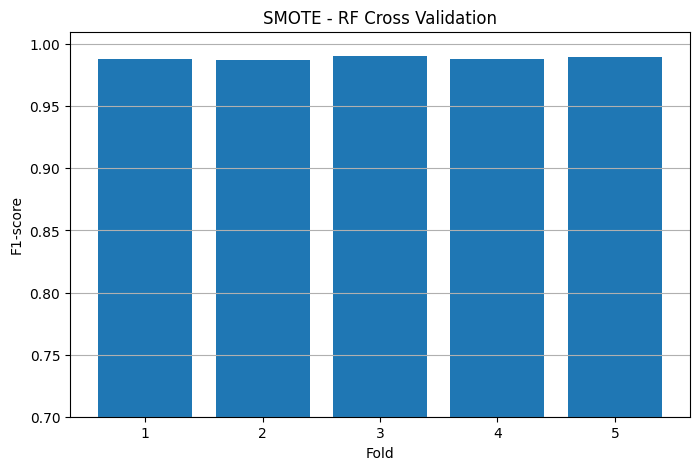

In [159]:
plt.figure(figsize=(8,5))

plt.bar(range(1,6), cv_scores)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("SMOTE - RF Cross Validation")
plt.ylim(0.7,1.01)
plt.grid(axis='y')

plt.show()

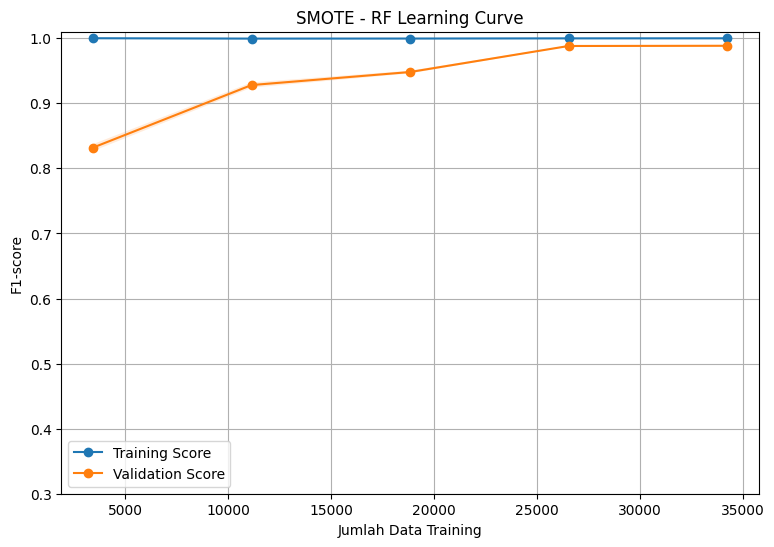

In [160]:
# Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model
model_rf_smote_lc = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Hitung learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_rf_smote_lc,
    X=X_train_smote,
    y=y_train_smote,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Rata-rata tiap fold
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(9,6))

plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

# Area deviasi
plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.15
)

plt.title("SMOTE - RF Learning Curve")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()
plt.ylim(0.3,1.01)

plt.show()

### **SMOTE - SVM**

=== SMOTE + SVM ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5348
           1       0.95      0.97      0.96      1099

    accuracy                           0.99      6447
   macro avg       0.97      0.98      0.98      6447
weighted avg       0.99      0.99      0.99      6447



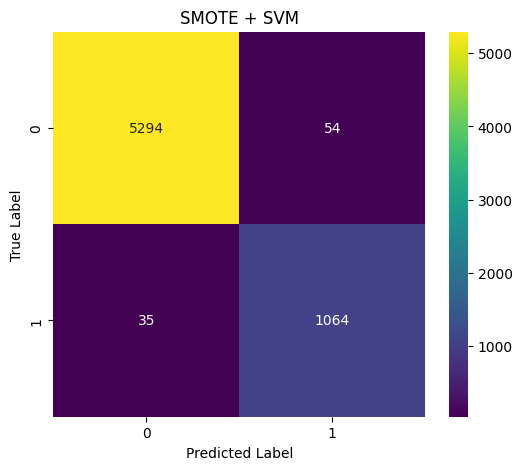

c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
2 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\li

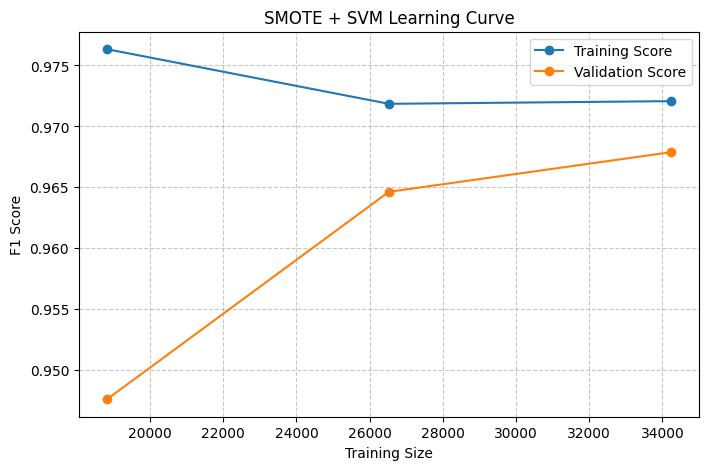

In [161]:
model_svm_smote = SVC(
    kernel='linear',
    probability=True,
    random_state=42
    )
model_svm_smote.fit(X_train_smote, y_train_smote)

evaluate_model(model_svm_smote, X_test_tfidf, y_test, "SMOTE + SVM")
plot_learning_curve(model_svm_smote, X_train_smote, y_train_smote, "SMOTE + SVM Learning Curve")

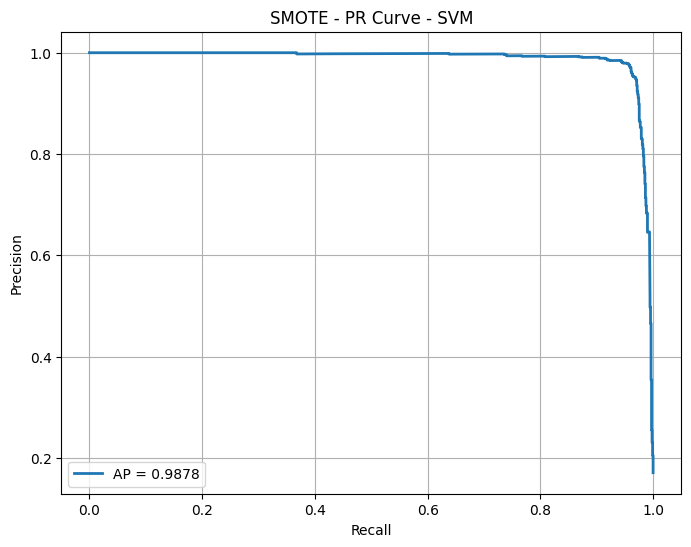

In [162]:
# Probabilitas kelas positif
y_score = model_svm_smote.predict_proba(X_test_tfidf)[:, 1]

# Hitung Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# Average Precision
ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision,
         linewidth=2,
         label=f'AP = {ap:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("SMOTE - PR Curve - SVM")
plt.grid(True)
plt.legend()
plt.show()

**Threshold Analysis**

In [163]:
threshold_list = np.arange(0.1, 1.0, 0.1)

results = []

for t in threshold_list:

    y_pred = (y_score >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        t,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(threshold_df)

   Threshold  Precision    Recall  F1-score
0        0.1   0.747412  0.985441  0.850078
1        0.2   0.826054  0.980892  0.896839
2        0.3   0.866613  0.975432  0.917808
3        0.4   0.895572  0.975432  0.933798
4        0.5   0.915312  0.973612  0.943563
5        0.6   0.935965  0.970883  0.953104
6        0.7   0.950045  0.969063  0.959459
7        0.8   0.957466  0.962693  0.960073
8        0.9   0.978565  0.955414  0.966851


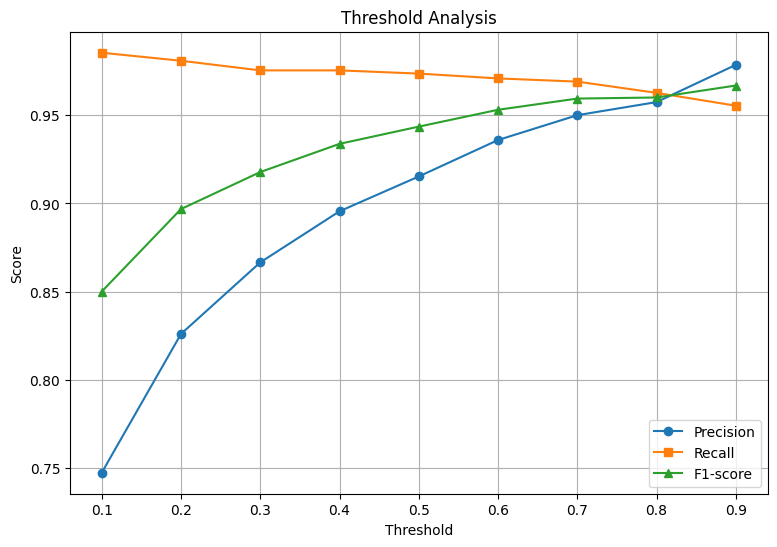

In [164]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='s',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker='^',
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.grid(True)
plt.legend()

plt.show()

**Cross-Validation Analysis**

In [165]:
# Cross Validation SMOTE + SVM
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_svm_smote_cv = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

cv_scores = cross_val_score(
    estimator=model_svm_smote_cv,
    X=X_train_smote,
    y=y_train_smote,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("===== Cross Validation SMOTE + SVM =====")
print("F1-score tiap fold :", cv_scores)
print("Mean F1-score      :", cv_scores.mean())
print("Std Dev            :", cv_scores.std())

===== Cross Validation SMOTE + SVM =====
F1-score tiap fold : [0.96867183 0.96905985 0.96726404 0.96657914 0.96870521]
Mean F1-score      : 0.9680560119698078
Std Dev            : 0.0009609121197271645


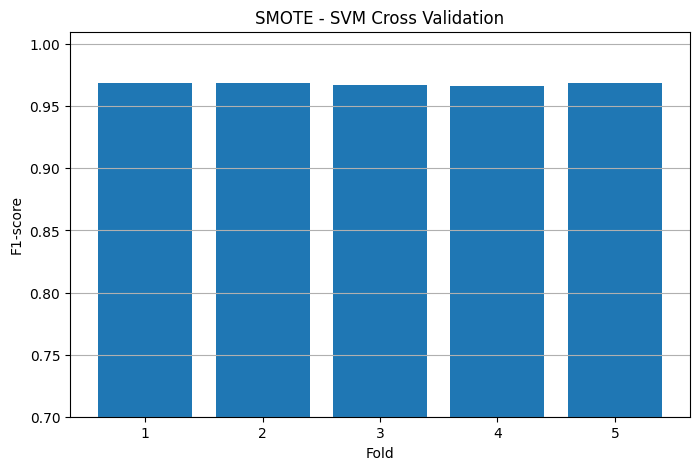

In [166]:
plt.figure(figsize=(8,5))

plt.bar(range(1,6), cv_scores)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("SMOTE - SVM Cross Validation")
plt.ylim(0.7,1.01)
plt.grid(axis='y')

plt.show()

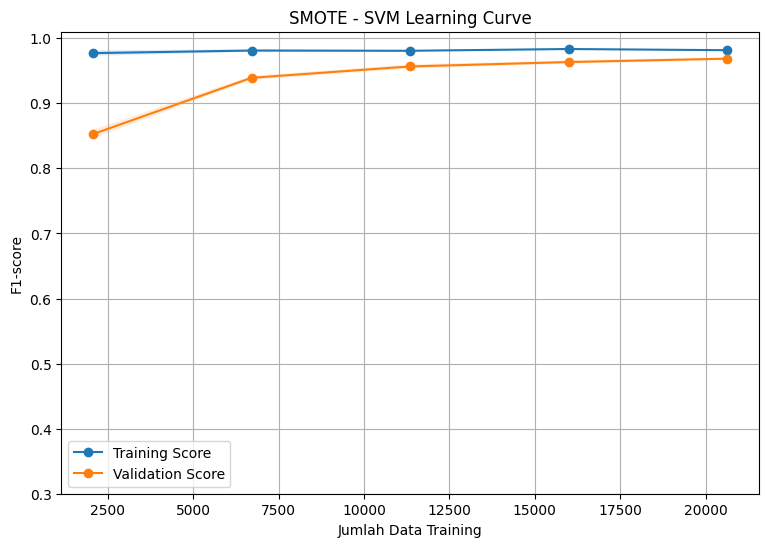

In [167]:
# Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model
model_svm_smote_lc = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

# Hitung learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_svm_smote_lc,
    X=X_train_tfidf,
    y=y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Rata-rata tiap fold
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(9,6))

plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

# Area deviasi
plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.15
)

plt.title("SMOTE - SVM Learning Curve")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()
plt.ylim(0.3,1.01)

plt.show()

## SKENARIO 3 - UNDERSAMPLING
Eksperimen undersampling bertujuan untuk mengatasi ketidakseimbangan data dengan mengurangi jumlah sampel pada kelas mayoritas sehingga distribusi kelas menjadi lebih seimbang. Eksperimen ini dilakukan untuk mengevaluasi pengaruh pengurangan data mayoritas terhadap performa model klasifikasi.

In [168]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_tfidf, y_train)

### **Undersampling - Logistic Regression**

=== UnderSampling - LR ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      5348
           1       0.89      0.95      0.92      1099

    accuracy                           0.97      6447
   macro avg       0.94      0.96      0.95      6447
weighted avg       0.97      0.97      0.97      6447



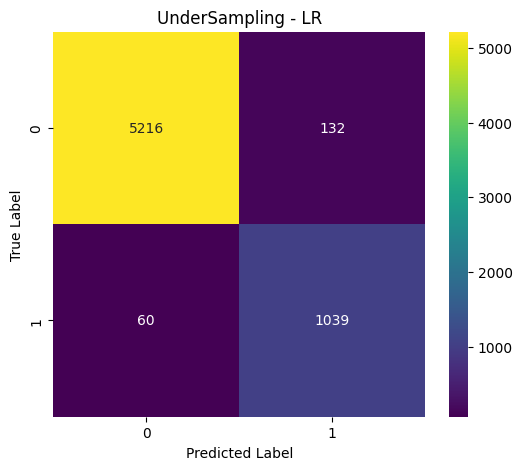

c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\

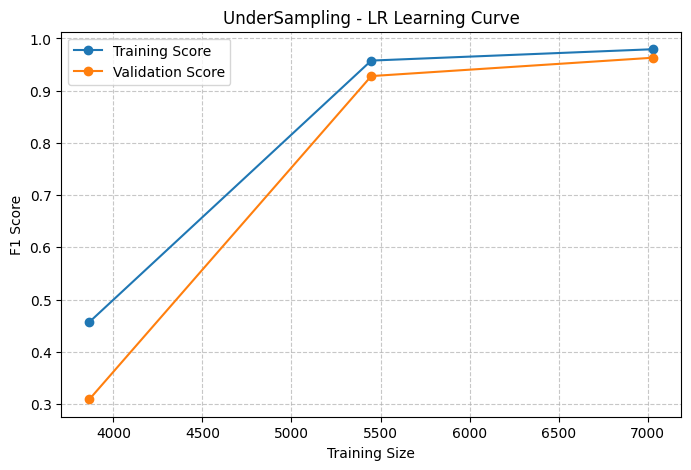

In [169]:
model_lr_under = LogisticRegression(max_iter=1000, random_state=42)
model_lr_under.fit(X_train_under, y_train_under)

evaluate_model(model_lr_under, X_test_tfidf, y_test, "UnderSampling - LR")
plot_learning_curve(model_lr_under, X_train_under, y_train_under, "UnderSampling - LR Learning Curve")

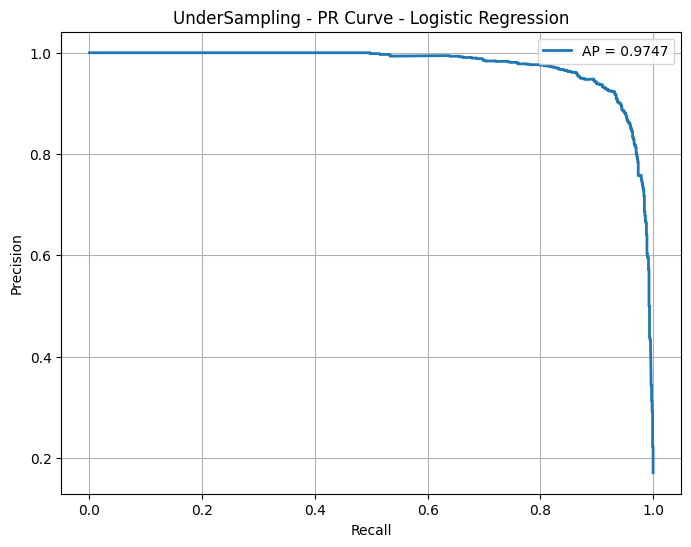

In [170]:
# Probabilitas kelas positif
y_score = model_lr_under.predict_proba(X_test_tfidf)[:, 1]

# Hitung Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# Average Precision
ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision,
         linewidth=2,
         label=f'AP = {ap:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("UnderSampling - PR Curve - Logistic Regression")
plt.grid(True)
plt.legend()
plt.show()

**Threshold Analysis**

In [171]:
threshold_list = np.arange(0.1, 1.0, 0.1)

results = []

for t in threshold_list:

    y_pred = (y_score >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        t,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(threshold_df)

   Threshold  Precision    Recall  F1-score
0        0.1   0.239111  0.999090  0.385872
1        0.2   0.471299  0.993631  0.639344
2        0.3   0.674549  0.986351  0.801183
3        0.4   0.812500  0.969973  0.884280
4        0.5   0.887276  0.945405  0.915419
5        0.6   0.937148  0.909008  0.922864
6        0.7   0.966527  0.840764  0.899270
7        0.8   0.983565  0.707916  0.823280
8        0.9   1.000000  0.453139  0.623669


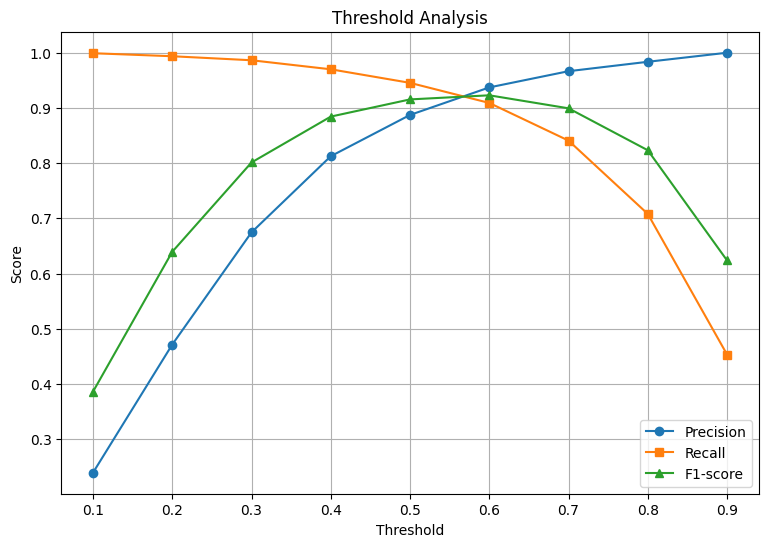

In [172]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='s',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker='^',
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.grid(True)
plt.legend()

plt.show()

**Cross-Validation Analysis**

In [173]:
# Cross Validation UnderSampling + Logistic Regression
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_lr_under_cv = LogisticRegression(
    max_iter=1000,
    random_state=42
)

cv_scores = cross_val_score(
    estimator=model_lr_under_cv,
    X=X_train_under,
    y=y_train_under,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("===== Cross Validation UnderSampling - LR =====")
print("F1-score tiap fold :", cv_scores)
print("Mean F1-score      :", cv_scores.mean())
print("Std Dev            :", cv_scores.std())

===== Cross Validation UnderSampling - LR =====
F1-score tiap fold : [0.96674312 0.96393818 0.9525463  0.96069364 0.95885714]
Mean F1-score      : 0.9605556759549365
Std Dev            : 0.004832804533327506


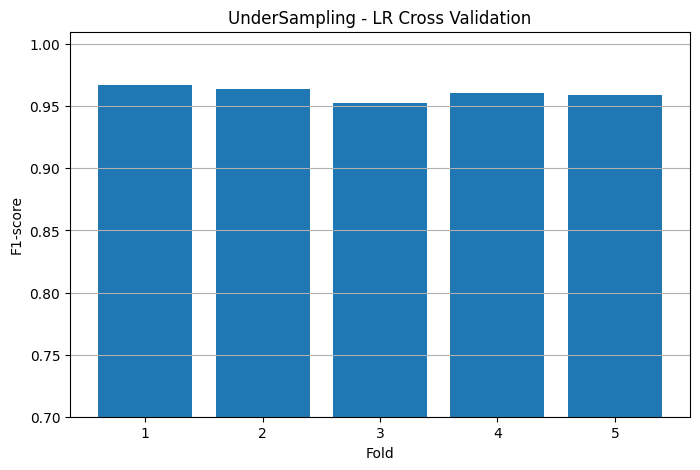

In [174]:
plt.figure(figsize=(8,5))

plt.bar(range(1,6), cv_scores)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("UnderSampling - LR Cross Validation")
plt.ylim(0.7,1.01)
plt.grid(axis='y')

plt.show()

c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\

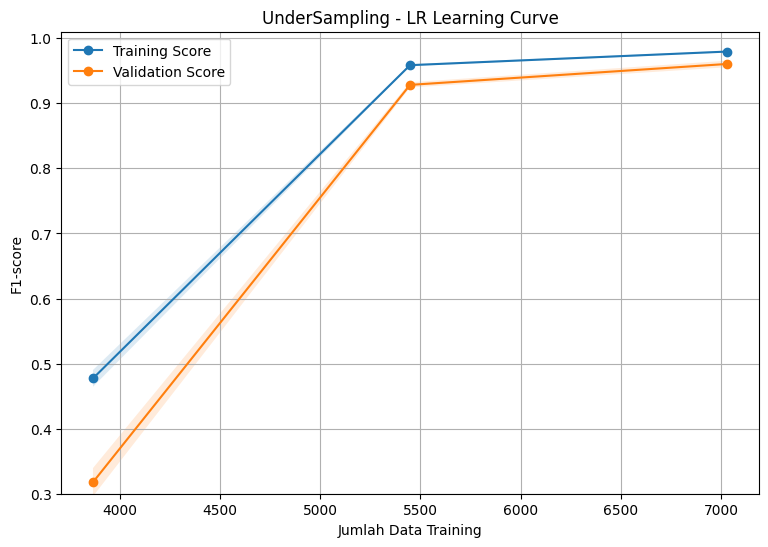

In [175]:
# Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model
model_lr_under_lc = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Hitung learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_lr_under_lc,
    X=X_train_under,
    y=y_train_under,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Rata-rata tiap fold
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(9,6))

plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

# Area deviasi
plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.15
)

plt.title("UnderSampling - LR Learning Curve")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()
plt.ylim(0.3,1.01)

plt.show()

### **Undersampling - Random Forest**

=== UnderSampling - RF ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      5348
           1       0.82      0.96      0.88      1099

    accuracy                           0.96      6447
   macro avg       0.90      0.96      0.93      6447
weighted avg       0.96      0.96      0.96      6447



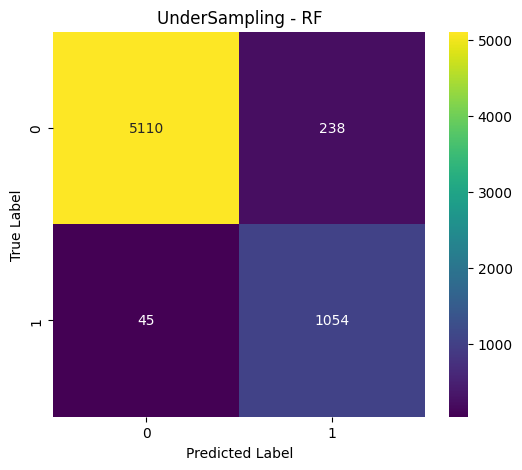

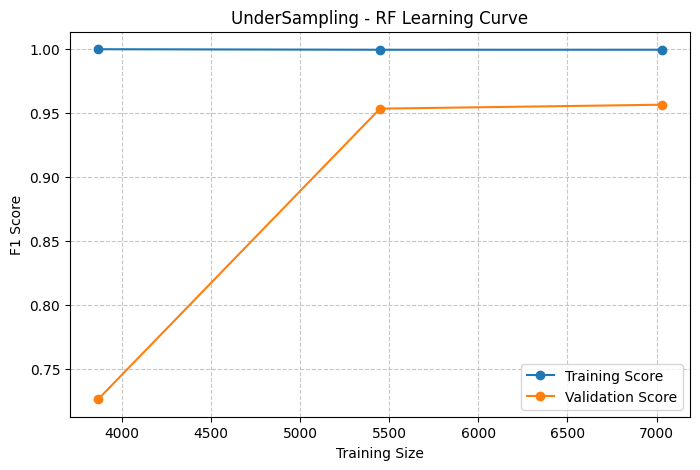

In [176]:
model_rf_under = RandomForestClassifier(n_estimators=200, random_state=42)
model_rf_under.fit(X_train_under, y_train_under)

evaluate_model(model_rf_under, X_test_tfidf, y_test, "UnderSampling - RF")
plot_learning_curve(model_rf_under, X_train_under, y_train_under, "UnderSampling - RF Learning Curve")

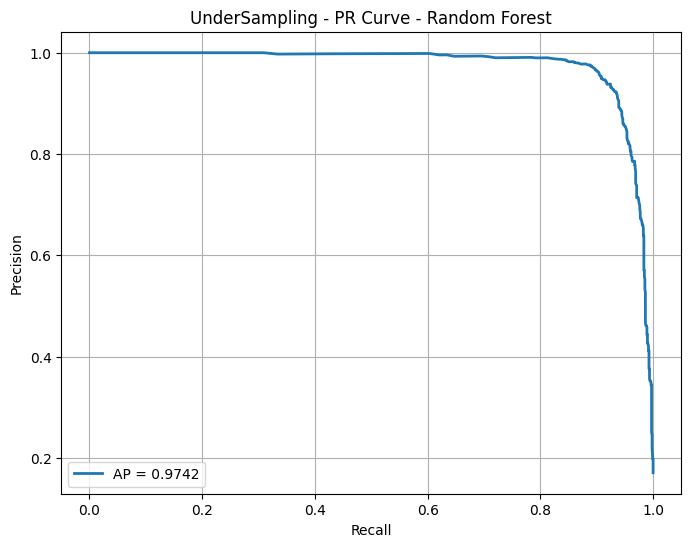

In [177]:
# Probabilitas kelas positif
y_score = model_rf_under.predict_proba(X_test_tfidf)[:, 1]

# Hitung Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# Average Precision
ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision,
         linewidth=2,
         label=f'AP = {ap:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("UnderSampling - PR Curve - Random Forest")
plt.grid(True)
plt.legend()
plt.show()

**Threshold Analysis**

In [178]:
threshold_list = np.arange(0.1, 1.0, 0.1)

results = []

for t in threshold_list:

    y_pred = (y_score >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        t,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(threshold_df)

   Threshold  Precision    Recall  F1-score
0        0.1   0.343476  0.996360  0.510847
1        0.2   0.442950  0.989081  0.611877
2        0.3   0.556584  0.984531  0.711140
3        0.4   0.684076  0.977252  0.804796
4        0.5   0.812645  0.959054  0.879800
5        0.6   0.898172  0.939035  0.918149
6        0.7   0.965753  0.898089  0.930693
7        0.8   0.989842  0.797998  0.883627
8        0.9   0.998366  0.555960  0.714202


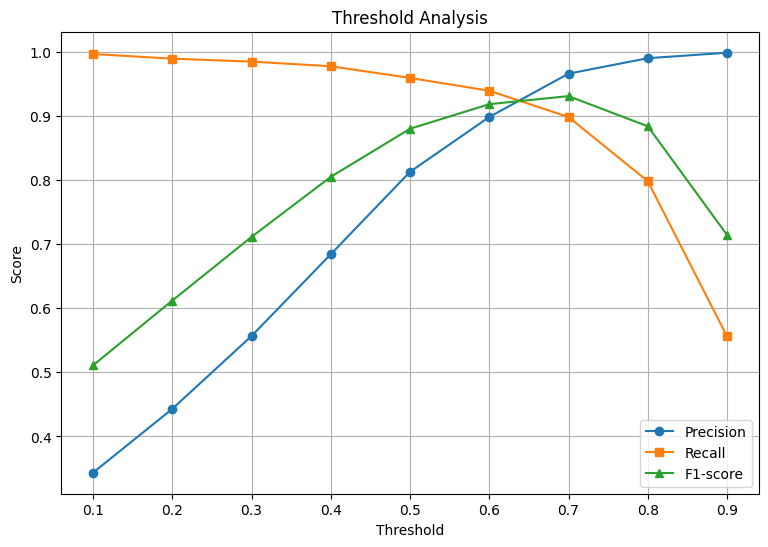

In [179]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='s',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker='^',
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.grid(True)
plt.legend()

plt.show()

**Cross-Validation Analysis**

===== UnderSampling - RF Cross Validation =====
F1-score tiap fold : [0.96071829 0.96188341 0.95050619 0.94968909 0.96112676]
Mean F1-score      : 0.9567847478589409
Std Dev            : 0.005478884703455581


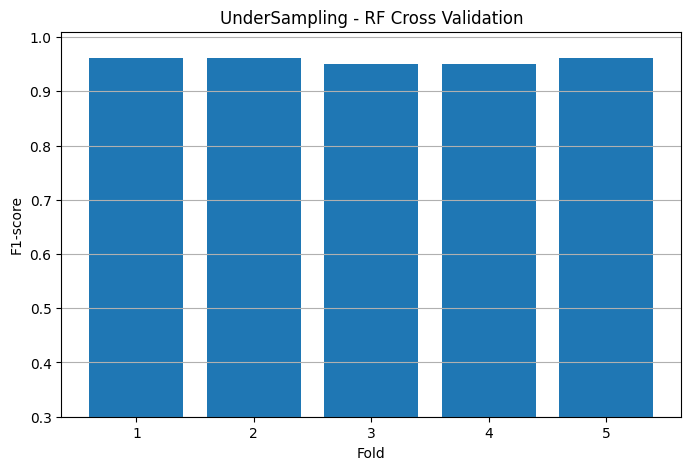

In [180]:
# Cross Validation UnderSampling + Random Forest
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_rf_under_cv = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

cv_scores = cross_val_score(
    estimator=model_rf_under_cv,
    X=X_train_under,
    y=y_train_under,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("===== UnderSampling - RF Cross Validation =====")
print("F1-score tiap fold :", cv_scores)
print("Mean F1-score      :", cv_scores.mean())
print("Std Dev            :", cv_scores.std())

plt.figure(figsize=(8,5))
plt.bar(range(1,6), cv_scores)
plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("UnderSampling - RF Cross Validation")
plt.ylim(0.3, 1.01)
plt.grid(axis='y')
plt.show()

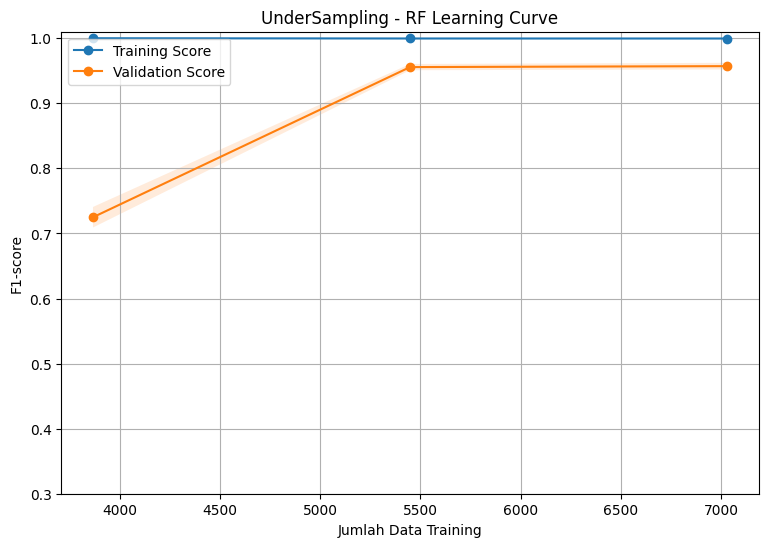

In [181]:
# Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model
model_rf_under_lc = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Hitung learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_rf_under_lc,
    X=X_train_under,
    y=y_train_under,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Rata-rata tiap fold
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(9,6))

plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

# Area deviasi
plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.15
)

plt.title("UnderSampling - RF Learning Curve")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()
plt.ylim(0.3,1.01)

plt.show()

### **UnderSampling - SVM**

=== Undersampling - SVM ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5348
           1       0.94      0.97      0.95      1099

    accuracy                           0.98      6447
   macro avg       0.97      0.98      0.97      6447
weighted avg       0.98      0.98      0.98      6447



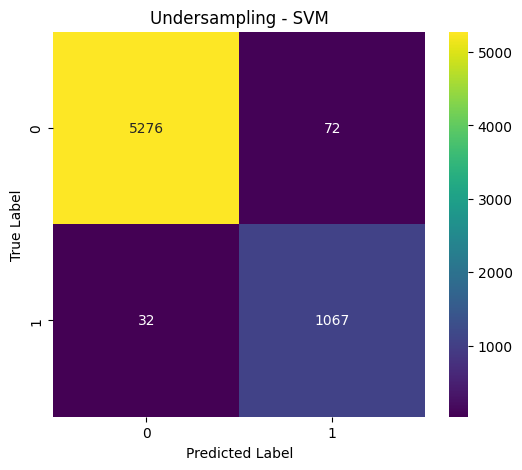

c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\

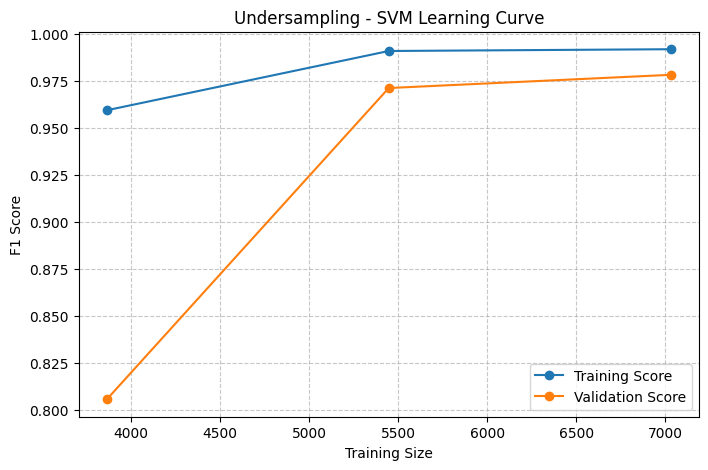

In [182]:
model_svm_under = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)
model_svm_under.fit(X_train_under, y_train_under)

evaluate_model(model_svm_under, X_test_tfidf, y_test, "Undersampling - SVM")
plot_learning_curve(model_svm_under, X_train_under, y_train_under, "Undersampling - SVM Learning Curve")

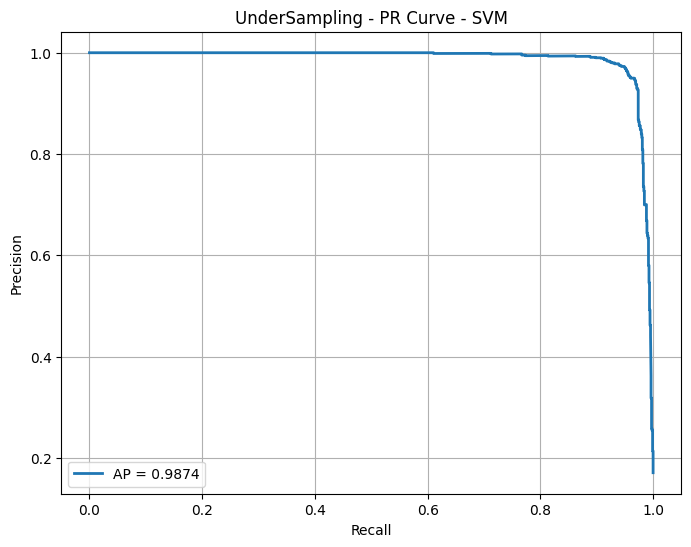

In [183]:
# Probabilitas kelas positif
y_score = model_svm_under.predict_proba(X_test_tfidf)[:, 1]

# Hitung Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

# Average Precision
ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision,
         linewidth=2,
         label=f'AP = {ap:.4f}')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("UnderSampling - PR Curve - SVM")
plt.grid(True)
plt.legend()
plt.show()

**Threshold Analysis**

In [184]:
threshold_list = np.arange(0.1, 1.0, 0.1)

results = []

for t in threshold_list:

    y_pred = (y_score >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        t,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print(threshold_df)

   Threshold  Precision    Recall  F1-score
0        0.1   0.764331  0.982712  0.859873
1        0.2   0.841282  0.979072  0.904962
2        0.3   0.873469  0.973612  0.920826
3        0.4   0.907549  0.973612  0.939421
4        0.5   0.927951  0.972702  0.949800
5        0.6   0.944938  0.968153  0.956404
6        0.7   0.953804  0.958144  0.955969
7        0.8   0.968489  0.950864  0.959596
8        0.9   0.980714  0.925387  0.952247


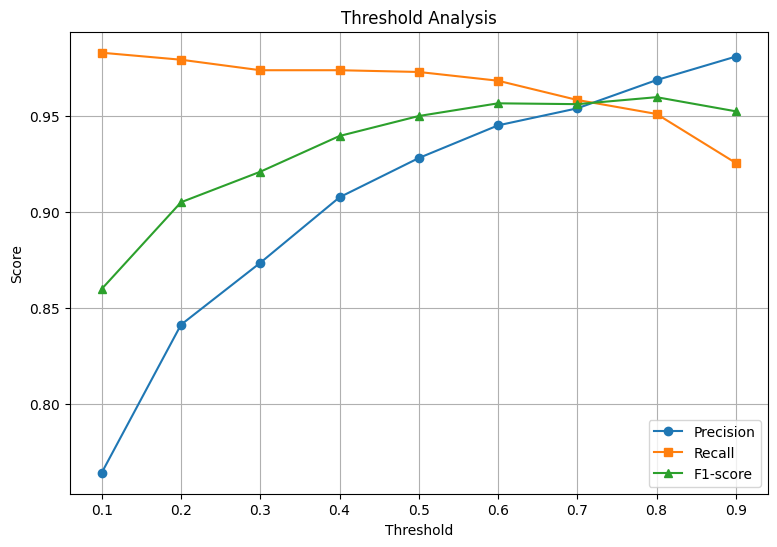

In [185]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='s',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker='^',
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.grid(True)
plt.legend()

plt.show()

**Cross-Validation Analysis**

In [186]:
# Cross Validation Undersampling + SVM
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_svm_under_cv = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

cv_scores = cross_val_score(
    estimator=model_svm_under_cv,
    X=X_train_under,
    y=y_train_under,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("===== UnderSampling - SVM Cross Validation =====")
print("F1-score tiap fold :", cv_scores)
print("Mean F1-score      :", cv_scores.mean())
print("Std Dev            :", cv_scores.std())

===== UnderSampling - SVM Cross Validation =====
F1-score tiap fold : [0.98111048 0.98345693 0.96962751 0.97284806 0.98407281]
Mean F1-score      : 0.9782231575905653
Std Dev            : 0.00587748669948243


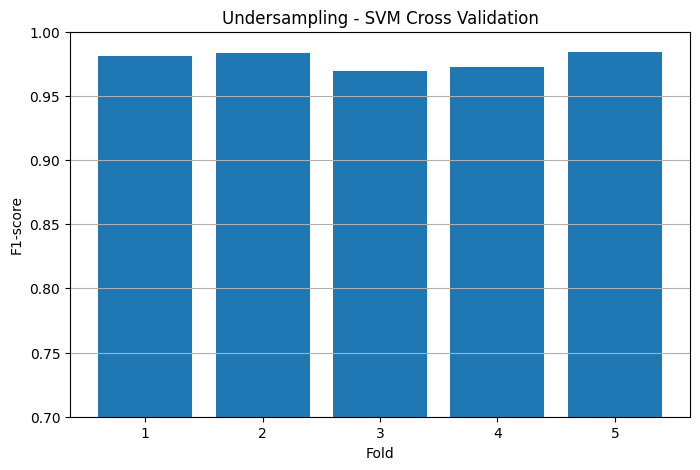

In [187]:
plt.figure(figsize=(8,5))

plt.bar(range(1,6), cv_scores)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Undersampling - SVM Cross Validation")
plt.ylim(0.7,1.0)
plt.grid(axis='y')

plt.show()

c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hp\Documents\Kuliah CS\SKRIPSI\judol\github\myenv\

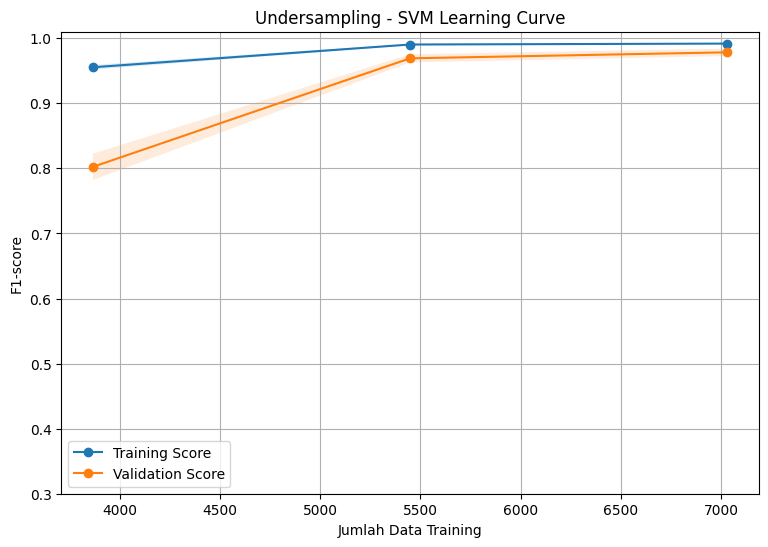

In [188]:
# Stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model
model_svm_under_lc = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

# Hitung learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_svm_under_lc,
    X=X_train_under,
    y=y_train_under,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Rata-rata tiap fold
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(9,6))

plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

# Area deviasi
plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_mean-val_std,
    val_mean+val_std,
    alpha=0.15
)

plt.title("Undersampling - SVM Learning Curve")
plt.xlabel("Jumlah Data Training")
plt.ylabel("F1-score")
plt.grid(True)
plt.legend()
plt.ylim(0.3,1.01)

plt.show()

## SKENARIO 4 - TF-IDF VARIATION (BIGRAM)
Eksperimen variasi TF-IDF dengan bigram bertujuan untuk mengevaluasi pengaruh penggunaan kombinasi dua kata berurutan (n-gram = 2) terhadap performa model klasifikasi. Pendekatan ini diharapkan mampu menangkap konteks frasa yang lebih spesifik dibandingkan representasi unigram, sehingga dapat meningkatkan kemampuan model dalam mengenali pola komentar promosi judi online.

In [189]:
X_train_bigram, X_test_bigram = tfidf_transform(
    X_train, X_test, max_features=5000, ngram_range=(1,2)
)

=== Bigram - LR ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      5348
           1       0.98      0.86      0.92      1099

    accuracy                           0.97      6447
   macro avg       0.98      0.93      0.95      6447
weighted avg       0.97      0.97      0.97      6447



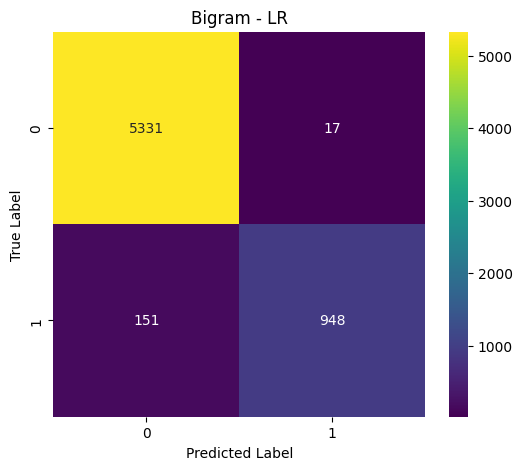

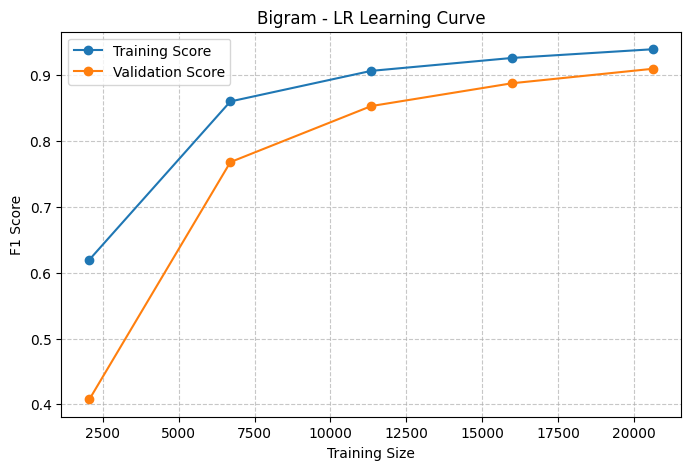

In [190]:
# Model Logistic Regression dengan Bigram
model_lr_bigram = LogisticRegression(max_iter=1000)
model_lr_bigram.fit(X_train_bigram, y_train)

evaluate_model(model_lr_bigram, X_test_bigram, y_test, "Bigram - LR")
plot_learning_curve(model_lr_bigram, X_train_bigram, y_train, "Bigram - LR Learning Curve")

=== Bigram - RF ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5348
           1       0.98      0.93      0.96      1099

    accuracy                           0.99      6447
   macro avg       0.98      0.96      0.97      6447
weighted avg       0.99      0.99      0.99      6447



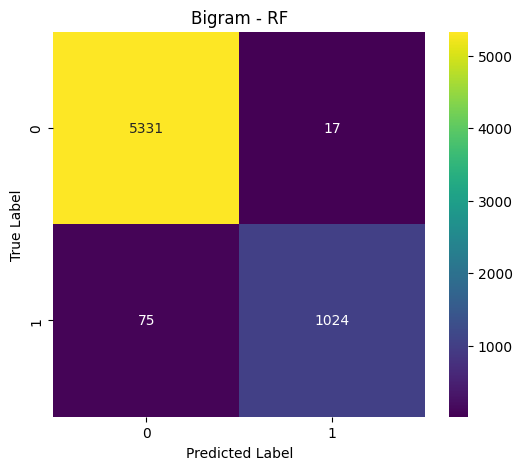

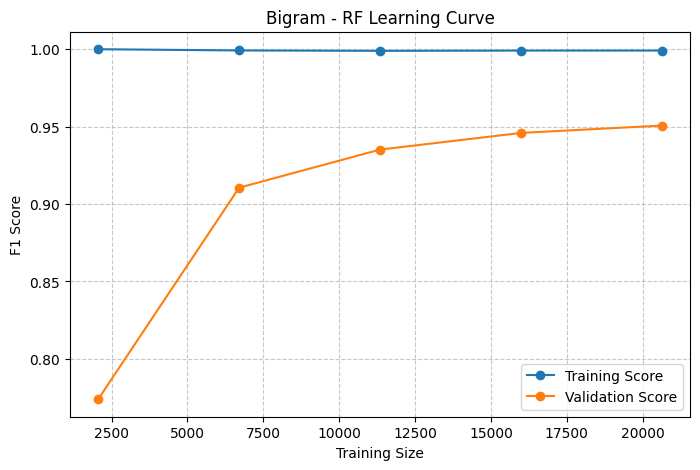

In [191]:
# Model Random Forest dengan Bigram
model_rf_bigram = RandomForestClassifier(n_estimators=200, random_state=42)
model_rf_bigram.fit(X_train_bigram, y_train)

evaluate_model(model_rf_bigram, X_test_bigram, y_test, "Bigram - RF")
plot_learning_curve(model_rf_bigram, X_train_bigram, y_train, "Bigram - RF Learning Curve")

=== Bigram - SVM ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5348
           1       0.99      0.94      0.97      1099

    accuracy                           0.99      6447
   macro avg       0.99      0.97      0.98      6447
weighted avg       0.99      0.99      0.99      6447



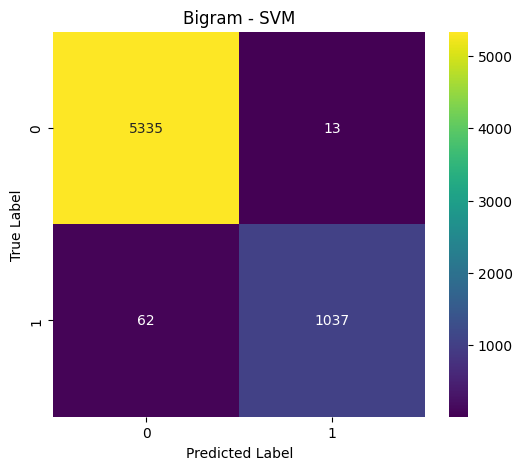

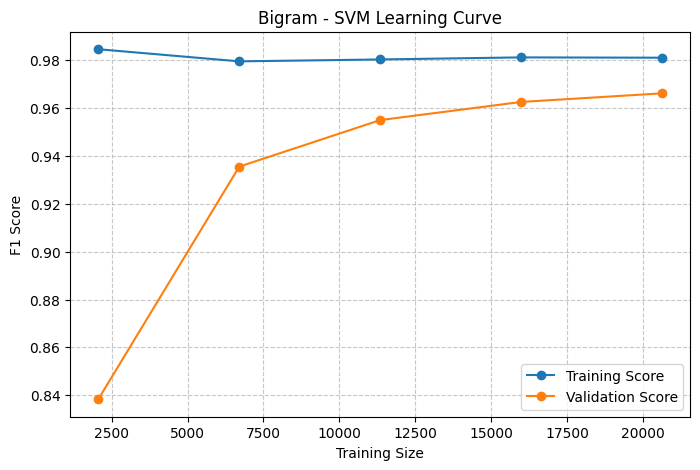

In [192]:
# Model Support Vector Machine dengan Bigram
model_svm_bigram = SVC(kernel='linear', probability=True, random_state=42)
model_svm_bigram.fit(X_train_bigram, y_train)

evaluate_model(model_svm_bigram, X_test_bigram, y_test, "Bigram - SVM")
plot_learning_curve(model_svm_bigram, X_train_bigram, y_train, "Bigram - SVM Learning Curve")

## SKENARIO 5 - HYPERPARAMETER TUNING

**Logistic Regression**

In [193]:
param_lr = [

    # L2 + LBFGS
    {
        'penalty': ['l2'],
        'solver': ['lbfgs'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'fit_intercept': [True, False],
        'tol': [1e-4, 1e-3],
        'class_weight': [None, 'balanced']
    },

    # L2 + SAGA
    {
        'penalty': ['l2'],
        'solver': ['saga'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'fit_intercept': [True, False],
        'tol': [1e-4, 1e-3],
        'class_weight': [None, 'balanced']
    },

    # L1 + LIBLINEAR
    {
        'penalty': ['l1'],
        'solver': ['liblinear'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'fit_intercept': [True, False],
        'tol': [1e-4, 1e-3],
        'class_weight': [None, 'balanced']
    },

    # L1 + SAGA
    {
        'penalty': ['l1'],
        'solver': ['saga'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'fit_intercept': [True, False],
        'tol': [1e-4, 1e-3],
        'class_weight': [None, 'balanced']
    },

    # Elastic Net
    {
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'l1_ratio': [0.2, 0.5, 0.8],
        'fit_intercept': [True, False],
        'tol': [1e-4, 1e-3],
        'class_weight': [None, 'balanced']
    }

]

Best Parameters : {'C': 100, 'class_weight': None, 'fit_intercept': True, 'penalty': 'l2', 'solver': 'saga', 'tol': 0.001}
Best CV F1 Score: 0.9678658655317861
=== Tuned Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5348
           1       0.98      0.95      0.96      1099

    accuracy                           0.99      6447
   macro avg       0.98      0.97      0.98      6447
weighted avg       0.99      0.99      0.99      6447



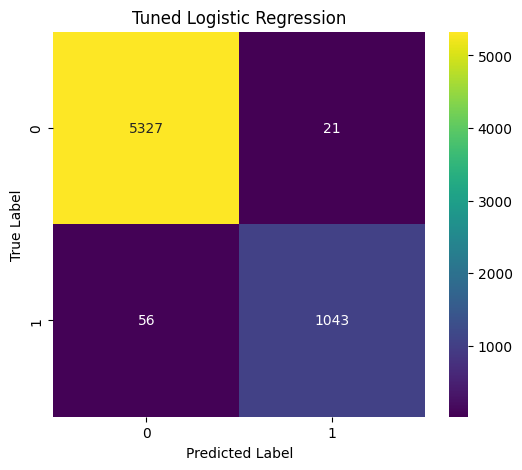

In [194]:
grid_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train_tfidf, y_train)

print("Best Parameters :", grid_lr.best_params_)
print("Best CV F1 Score:", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_

evaluate_model(
    best_lr,
    X_test_tfidf,
    y_test,
    "Tuned Logistic Regression"
)

**RF**

In [195]:
param_rf = {

    'n_estimators': [100, 200, 300],

    'criterion': [
        'gini',
        'entropy'
    ],

    'max_depth': [
        10,
        20,
        None
    ],

    'min_samples_split': [
        2,
        5
    ],

    'min_samples_leaf': [
        1,
        2
    ],

    'max_features': [
        'sqrt',
        'log2'
    ],

    'bootstrap': [
        True
    ],

    'class_weight': [
        None,
        'balanced'
    ]

}

Best Parameters : {'bootstrap': True, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best CV F1 Score: 0.953075467210146
=== Tuned Random Forest ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5348
           1       0.98      0.93      0.96      1099

    accuracy                           0.99      6447
   macro avg       0.98      0.96      0.97      6447
weighted avg       0.99      0.99      0.99      6447



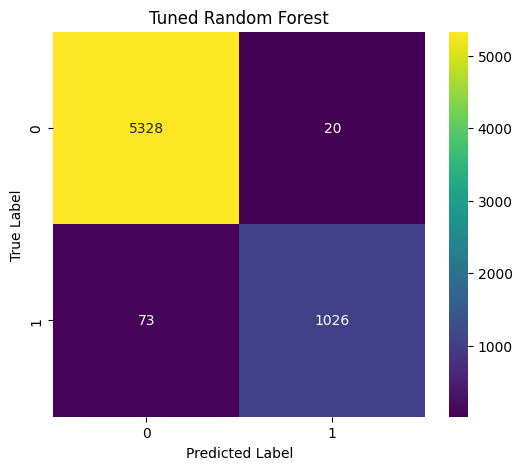

In [196]:
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=param_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train_tfidf, y_train)

print("Best Parameters :", grid_rf.best_params_)
print("Best CV F1 Score:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

evaluate_model(
    best_rf,
    X_test_tfidf,
    y_test,
    "Tuned Random Forest"
)

**SVM**

In [197]:
param_svm = {

    'C': [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ],

    'kernel': [
        'linear'
    ],

    'class_weight': [
        None,
        'balanced'
    ],

    'tol': [
        1e-4,
        1e-3,
        1e-2
    ],

    'shrinking': [
        True,
        False
    ]

}


Best Parameters : {'C': 1, 'class_weight': None, 'kernel': 'linear', 'shrinking': False, 'tol': 0.01}
Best CV F1 Score: 0.967342353293305
=== Tuned SVM ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5348
           1       0.98      0.95      0.97      1099

    accuracy                           0.99      6447
   macro avg       0.99      0.97      0.98      6447
weighted avg       0.99      0.99      0.99      6447



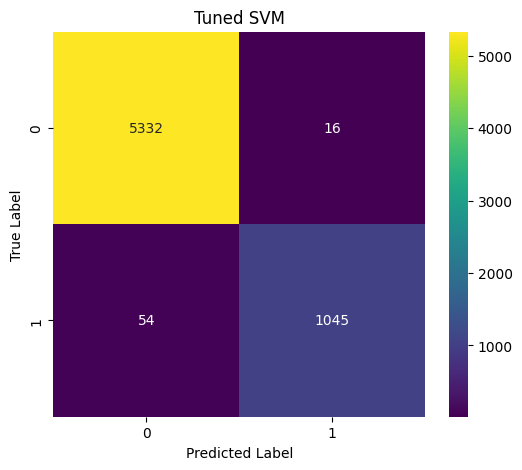

In [198]:
grid_svm = GridSearchCV(

    estimator=SVC(
        probability=True
    ),

    param_grid=param_svm,

    cv=5,

    scoring='f1',

    n_jobs=-1

)

grid_svm.fit(X_train_tfidf, y_train)

print("Best Parameters :", grid_svm.best_params_)
print("Best CV F1 Score:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_

evaluate_model(
    best_svm,
    X_test_tfidf,
    y_test,
    "Tuned SVM"
)

## Perbandingan Hasil Evaluasi Model

In [199]:
from numpy import add


results = []

def add_result(name, model, X_test, y_test):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

# Tambahkan hasil
add_result("Baseline LR", model_lr, X_test_tfidf, y_test)
add_result("Baseline SVM", model_svm, X_test_tfidf, y_test)
add_result("Baseline RF", model_rf, X_test_tfidf, y_test)
add_result("SMOTE + LR", model_lr_smote, X_test_tfidf, y_test)
add_result("SMOTE + SVM", model_svm_smote, X_test_tfidf, y_test)
add_result("SMOTE + RF", model_rf_smote, X_test_tfidf, y_test)
add_result("Undersampling + LR", model_lr_under, X_test_tfidf, y_test)
add_result("Undersampling + RF", model_rf_under, X_test_tfidf, y_test)
add_result("Undersampling + SVM", model_svm_under, X_test_tfidf, y_test)
add_result("Tuned LR", best_lr, X_test_tfidf, y_test)
add_result("Tuned RF", best_rf, X_test_tfidf, y_test)
add_result("Tuned SVM", best_svm, X_test_tfidf, y_test)

df_results = pd.DataFrame(results)
df_results

,Model,Accuracy,Precision,Recall,F1
0,Baseline LR,0.979060,0.924296,0.955414,0.939597
1,Baseline SVM,0.986816,0.960909,0.961783,0.961346
2,Baseline RF,0.981232,0.980354,0.908098,0.942844
3,SMOTE + LR,0.979215,0.921397,0.959964,0.940285
4,SMOTE + SVM,0.986195,0.951699,0.968153,0.959856
5,SMOTE + RF,0.979991,0.950743,0.930846,0.940690
6,Undersampling + LR,0.970219,0.887276,0.945405,0.915419
7,Undersampling + RF,0.956104,0.815789,0.959054,0.881639
8,Undersampling + SVM,0.983868,0.936787,0.970883,0.953530
9,Tuned LR,0.988056,0.980263,0.949045,0.964401


## Visualisasi Perbandingan

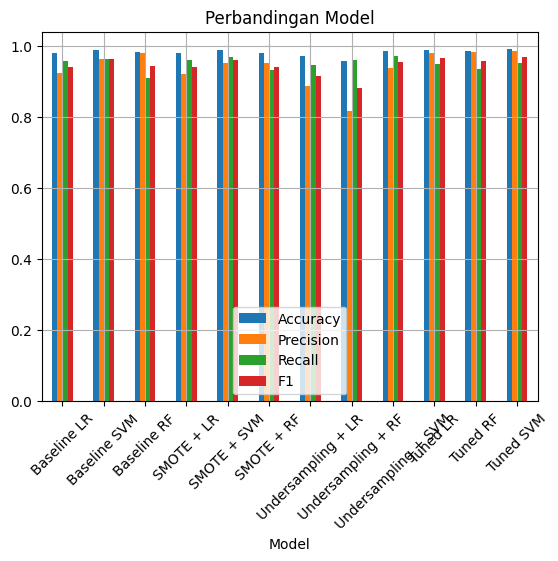

In [200]:
df_results.set_index("Model")[["Accuracy","Precision","Recall","F1"]].plot(kind="bar")
plt.title("Perbandingan Model")
plt.xticks(rotation=45)
plt.grid()
plt.show()